In [1]:
!pip install thop


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# PDC Aspect(Sequential)

## HF Pneumonia

In [5]:
import sys

MEDVIT_DIR = r"C:\Users\hassa\OneDrive\Desktop\sem6\ANN\multimodal\MEDVIT\MedViTV2-main"

if MEDVIT_DIR not in sys.path:
    sys.path.insert(0, MEDVIT_DIR)
MEDFORMER_DIR = r"C:\Users\hassa\OneDrive\Desktop\sem6\ANN\multimodal\MedFormer-main"

if MEDFORMER_DIR not in sys.path:
    sys.path.insert(0, MEDFORMER_DIR)

## ISIC 2018

Device: cuda
Train: 9221 | Val: 1153 | Test: 1153
initialize_weights...
Epoch 1 | Loss 0.8538 | Val Acc 0.7528
Epoch 2 | Loss 0.6554 | Val Acc 0.7710
Epoch 3 | Loss 0.5930 | Val Acc 0.7866
Epoch 4 | Loss 0.5498 | Val Acc 0.7788
Epoch 5 | Loss 0.5205 | Val Acc 0.7832

──────── FINAL RESULTS ────────
Training Time: 520.1815509796143
Accuracy : 0.7858
Precision: 0.7739
Recall   : 0.7858
F1 Score : 0.7644


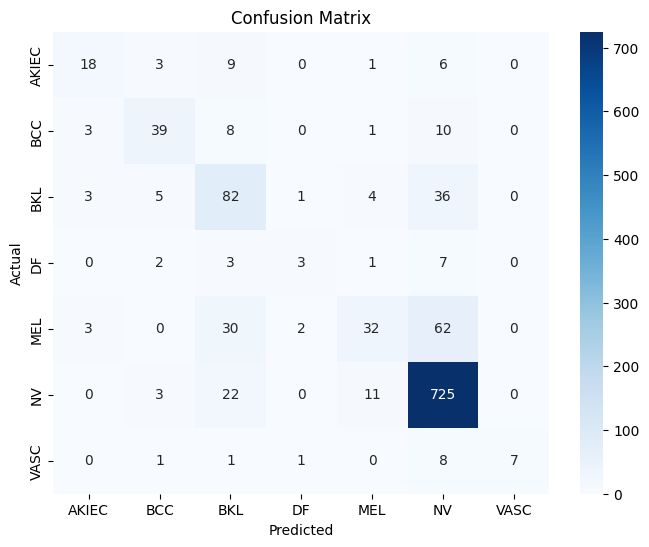

In [6]:
import os
import time
import sys
import torch
import torch.nn as nn
import timm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from thop import profile
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from torchvision.transforms import (
    Compose, Resize, CenterCrop,
    RandomHorizontalFlip, RandomRotation,
    ToTensor, Normalize
)
from torch.utils.data import DataLoader
from PIL import Image

# ─────────────────────────────
# DEVICE
# ─────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ─────────────────────────────
# PATHS
# ─────────────────────────────
ROOT = r"C:\Users\hassa\OneDrive\Desktop\sem6\ANN\multimodal\ISIC2018"

TRAIN_DIR = os.path.join(ROOT, "ISIC2018_Train", "Categorized")
TEST_DIR  = os.path.join(ROOT, "ISIC2018_Test", "Categorized")

MEDVIT_DIR = r"C:\Users\hassa\OneDrive\Desktop\sem6\ANN\multimodal\MEDVIT\MedViTV2-main"
MEDFORMER_DIR = r"C:\Users\hassa\OneDrive\Desktop\sem6\ANN\multimodal\MedFormer-main"

sys.path.insert(0, MEDVIT_DIR)
sys.path.insert(0, MEDFORMER_DIR)

from MedViT import MedViT_tiny
from models.medformer import medformer_tiny

# ─────────────────────────────
# LOAD DATA
# ─────────────────────────────
classes = sorted([c for c in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, c))])
label2id = {c: i for i, c in enumerate(classes)}

def load_folder(folder):
    imgs, labels = [], []
    for c in classes:
        path = os.path.join(folder, c)
        for f in os.listdir(path):
            imgs.append(os.path.join(path, f))
            labels.append(label2id[c])
    return imgs, labels

train_imgs, train_labels = load_folder(TRAIN_DIR)
test_imgs, test_labels   = load_folder(TEST_DIR)

all_imgs = train_imgs + test_imgs
all_labels = train_labels + test_labels

# Stratified split (70-15-15)
x_train, x_temp, y_train, y_temp = train_test_split(
    all_imgs, all_labels, test_size=0.2,
    stratify=all_labels, random_state=42
)

x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.5,
    stratify=y_temp, random_state=42
)

print(f"Train: {len(x_train)} | Val: {len(x_val)} | Test: {len(x_test)}")

# ─────────────────────────────
# TRANSFORMS
# ─────────────────────────────
SIZE = 224

train_tf = Compose([
    Resize((SIZE, SIZE)),
    RandomHorizontalFlip(),
    RandomRotation(10),
    ToTensor(),
    Normalize(mean=(0.5,)*3, std=(0.5,)*3),
])

eval_tf = Compose([
    Resize((SIZE, SIZE)),
    CenterCrop(SIZE),
    ToTensor(),
    Normalize(mean=(0.5,)*3, std=(0.5,)*3),
])

# ─────────────────────────────
# DATASET
# ─────────────────────────────
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, x, y, tf):
        self.x = x
        self.y = y
        self.tf = tf

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        img = Image.open(self.x[idx]).convert("RGB")
        return self.tf(img), self.y[idx]

train_loader = DataLoader(CustomDataset(x_train, y_train, train_tf), batch_size=16, shuffle=True)
val_loader   = DataLoader(CustomDataset(x_val, y_val, eval_tf), batch_size=16)
test_loader  = DataLoader(CustomDataset(x_test, y_test, eval_tf), batch_size=16)

# ─────────────────────────────
# MODELS
# ─────────────────────────────
deit = timm.create_model("deit_base_patch16_224", pretrained=True)
deit.head = nn.Identity()

class DeiTBackbone(nn.Module):
    def __init__(self, m):
        super().__init__()
        self.m = m
    def forward(self, x):
        return self.m.forward_features(x)[:, 0]

# MedViT
medvit = MedViT_tiny(num_classes=7)
medvit.proj_head = nn.Identity()
medvit.load_state_dict(torch.load(
    r"C:\Users\hassa\OneDrive\Desktop\sem6\ANN\multimodal\Pretrained Models\MedViT_tiny_ISIC2018.pth",
    map_location=DEVICE
), strict=False)

class MedViTBackbone(nn.Module):
    def __init__(self, m):
        super().__init__()
        self.m = m
    def forward(self, x):
        return self.m(x)

# MedFormer
medformer = medformer_tiny(num_classes=4)
medformer.head = nn.Identity()
medformer.load_state_dict(torch.load(
    r"C:\Users\hassa\OneDrive\Desktop\sem6\ANN\multimodal\Pretrained Models\Medformer_tiny_BT.pth",
    map_location=DEVICE,
    weights_only=False
), strict=False)

class MedFormerBackbone(nn.Module):
    def __init__(self, m):
        super().__init__()
        self.m = m
    def forward(self, x):
        x = self.m.forward_features(x)
        return x.flatten(2).mean(-1)

# ─────────────────────────────
# FUSION MODEL
# ─────────────────────────────
class FusionModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.deit = DeiTBackbone(deit).to(DEVICE)
        self.medvit = MedViTBackbone(medvit).to(DEVICE)
        self.medformer = MedFormerBackbone(medformer).to(DEVICE)

        self.p1 = nn.Linear(768, 256)
        self.p2 = nn.Linear(384, 256)
        self.p3 = nn.Linear(256, 256)

        self.classifier = nn.Sequential(
            nn.Linear(256 * 3, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        f1 = self.p1(self.deit(x))
        f2 = self.p2(self.medvit(x))
        f3 = self.p3(self.medformer(x))
        return self.classifier(torch.cat([f1, f2, f3], dim=1))

model = FusionModel(len(classes)).to(DEVICE)

# Freeze backbones
for m in [model.deit, model.medvit, model.medformer]:
    for p in m.parameters():
        p.requires_grad = False

# ─────────────────────────────
# TRAINING SETUP
# ─────────────────────────────
opt = torch.optim.AdamW(
    list(model.p1.parameters()) +
    list(model.p2.parameters()) +
    list(model.p3.parameters()) +
    list(model.classifier.parameters()),
    lr=1e-4
)

criterion = nn.CrossEntropyLoss()

# ─────────────────────────────
# TRAIN FUNCTION
# ─────────────────────────────
def train_epoch():
    model.train()
    total = 0

    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        opt.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        opt.step()

        total += loss.item()

    return total / len(train_loader)

# ─────────────────────────────
# EVALUATION
# ─────────────────────────────
def evaluate(loader):
    model.eval()
    correct = total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            pred = model(x).argmax(1)

            correct += (pred == y).sum().item()
            total += y.size(0)

    return correct / total

def evaluate_full(loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            preds = model(x).argmax(1).cpu().numpy()

            y_pred.extend(preds)
            y_true.extend(y.numpy())

    return y_true, y_pred

# ─────────────────────────────
# TRAIN LOOP
# ─────────────────────────────
start = time.time()

for epoch in range(5):
    loss = train_epoch()
    val_acc = evaluate(val_loader)
    print(f"Epoch {epoch+1} | Loss {loss:.4f} | Val Acc {val_acc:.4f}")

end = time.time()

# ─────────────────────────────
# FINAL METRICS
# ─────────────────────────────
y_true, y_pred = evaluate_full(test_loader)

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average="weighted")
rec  = recall_score(y_true, y_pred, average="weighted")
f1   = f1_score(y_true, y_pred, average="weighted")

print("\n──────── FINAL RESULTS ────────")
print("Training Time:", end - start)
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")

# ─────────────────────────────
# CONFUSION MATRIX
# ─────────────────────────────
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes,
            yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## BT 

In [2]:
import sys
MEDVIT_DIR = r"C:\Users\hassa\OneDrive\Desktop\sem6\ANN\multimodal\MEDVIT\MedViTV2-main"
MEDFORMER_DIR = r"C:\Users\hassa\OneDrive\Desktop\sem6\ANN\multimodal\MedFormer-main"

sys.path.insert(0, MEDVIT_DIR)
sys.path.insert(0, MEDFORMER_DIR)

Device: cuda
initialize_weights...
TOTAL FLOPs: 18505626080.0
1 | Loss 0.5669 | Val Acc 0.9145
2 | Loss 0.2764 | Val Acc 0.9231
3 | Loss 0.2155 | Val Acc 0.9330
4 | Loss 0.1752 | Val Acc 0.9416
5 | Loss 0.1546 | Val Acc 0.9416

──────── FINAL RESULTS ────────
Accuracy  : 0.9246
Precision : 0.9233
Recall    : 0.9207
F1 Score  : 0.9195
Training Time: 201.76097798347473


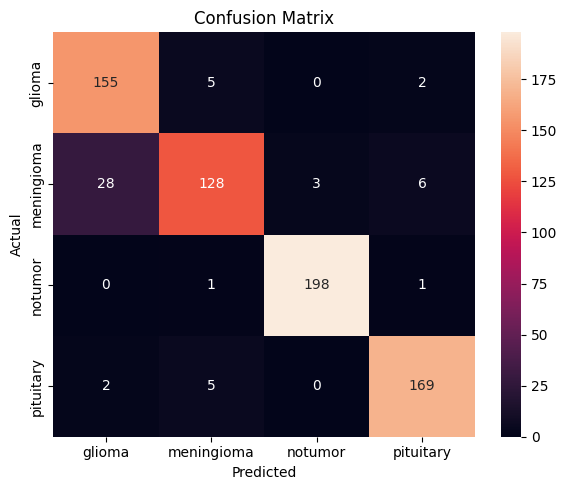

In [4]:
import os
import time
import torch
import torch.nn as nn
import timm
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from torchvision.transforms import *
from thop import profile

# METRICS
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ─────────────────────────────
# DEVICE
# ─────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ─────────────────────────────
# DATA
# ─────────────────────────────
DATA_DIR = r"C:\Users\hassa\OneDrive\Desktop\sem6\ANN\multimodal\Brain_Tumor_MRI_Classification\Brain_Tumor_MRI_Classification"

train_dir = os.path.join(DATA_DIR, "train")
val_dir   = os.path.join(DATA_DIR, "val")

classes = sorted(os.listdir(train_dir))
label2id = {c:i for i,c in enumerate(classes)}

def load(folder):
    imgs, labels = [], []
    for c in classes:
        p = os.path.join(folder, c)
        for f in os.listdir(p):
            imgs.append(os.path.join(p, f))
            labels.append(label2id[c])
    return imgs, labels

train_imgs, train_labels = load(train_dir)
val_imgs, val_labels = load(val_dir)

all_imgs = train_imgs + val_imgs
all_labels = train_labels + val_labels

# Stratified split
x_train, x_temp, y_train, y_temp = train_test_split(
    all_imgs, all_labels, test_size=0.2, stratify=all_labels, random_state=42
)

x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

# ─────────────────────────────
# DATASET
# ─────────────────────────────
SIZE = 224

tf = Compose([
    Resize((SIZE, SIZE)),
    ToTensor(),
    Normalize((0.5,)*3, (0.5,)*3)
])

class BrainDS(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __len__(self):
        return len(self.x)

    def __getitem__(self, i):
        img = Image.open(self.x[i]).convert("RGB")
        return tf(img), self.y[i]

train_loader = DataLoader(BrainDS(x_train, y_train), batch_size=16, shuffle=True)
val_loader   = DataLoader(BrainDS(x_val, y_val), batch_size=16)
test_loader  = DataLoader(BrainDS(x_test, y_test), batch_size=16)

# ─────────────────────────────
# BACKBONES (PRETRAINED)
# ─────────────────────────────
deit = timm.create_model("deit_base_patch16_224", pretrained=True)
deit.head = nn.Identity()

class DeiTBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.m = deit
    def forward(self, x):
        return self.m.forward_features(x)[:, 0]

# MedViT
from MedViT import MedViT_tiny
medvit = MedViT_tiny(num_classes=7)
medvit.proj_head = nn.Identity()
medvit.load_state_dict(torch.load(
    r"C:\Users\hassa\OneDrive\Desktop\sem6\ANN\multimodal\Pretrained Models\MedViT_tiny_ISIC2018.pth",
    map_location=DEVICE
), strict=False)

class MedViTBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.m = medvit
    def forward(self, x):
        return self.m(x)

# MedFormer
from models.medformer import medformer_tiny
medformer = medformer_tiny(num_classes=4)
medformer.head = nn.Identity()
medformer.load_state_dict(torch.load(
    r"C:\Users\hassa\OneDrive\Desktop\sem6\ANN\multimodal\Pretrained Models\Medformer_tiny_BT.pth",
    map_location=DEVICE,
    weights_only=False
), strict=False)

class MedFormerBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.m = medformer
    def forward(self, x):
        x = self.m.forward_features(x)
        return x.flatten(2).mean(-1)

# ─────────────────────────────
# FUSION MODEL
# ─────────────────────────────
class Fusion(nn.Module):
    def __init__(self):
        super().__init__()

        self.deit = DeiTBackbone().to(DEVICE)
        self.medvit = MedViTBackbone().to(DEVICE)
        self.medformer = MedFormerBackbone().to(DEVICE)

        self.p1 = nn.Linear(768, 256)
        self.p2 = nn.Linear(384, 256)
        self.p3 = nn.Linear(256, 256)

        self.cls = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, len(classes))
        )

    def forward(self, x):
        f1 = self.p1(self.deit(x))
        f2 = self.p2(self.medvit(x))
        f3 = self.p3(self.medformer(x))
        return self.cls(torch.cat([f1, f2, f3], dim=1))

model = Fusion().to(DEVICE)

# Freeze backbones
for m in [model.deit, model.medvit, model.medformer]:
    for p in m.parameters():
        p.requires_grad = False

# ─────────────────────────────
# FLOPs
# ─────────────────────────────
dummy = torch.randn(1, 3, 224, 224).to(DEVICE)

f1,_ = profile(model.deit, inputs=(dummy,), verbose=False)
f2,_ = profile(model.medvit, inputs=(dummy,), verbose=False)
f3,_ = profile(model.medformer, inputs=(dummy,), verbose=False)

print("TOTAL FLOPs:", f1+f2+f3)

# ─────────────────────────────
# TRAINING
# ─────────────────────────────
opt = torch.optim.AdamW(
    list(model.p1.parameters()) +
    list(model.p2.parameters()) +
    list(model.p3.parameters()) +
    list(model.cls.parameters()),
    lr=1e-4
)

loss_fn = nn.CrossEntropyLoss()

def train():
    model.train()
    total = 0
    for x,y in train_loader:
        x,y = x.to(DEVICE), y.to(DEVICE)

        opt.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward()
        opt.step()

        total += loss.item()

    return total/len(train_loader)

def evaluate_full(loader):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x,y in loader:
            x,y = x.to(DEVICE), y.to(DEVICE)

            preds = model(x).argmax(1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    return all_labels, all_preds

# ─────────────────────────────
# TRAIN LOOP
# ─────────────────────────────
start = time.time()

for e in range(5):
    loss = train()

    val_true, val_pred = evaluate_full(val_loader)
    val_acc = accuracy_score(val_true, val_pred)

    print(f"{e+1} | Loss {loss:.4f} | Val Acc {val_acc:.4f}")

end = time.time()

# ─────────────────────────────
# FINAL EVALUATION
# ─────────────────────────────
y_true, y_pred = evaluate_full(test_loader)

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='macro')
rec = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print("\n──────── FINAL RESULTS ────────")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")
print("Training Time:", end - start)

# ─────────────────────────────
# CONFUSION MATRIX
# ─────────────────────────────
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=classes,
            yticklabels=classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

## Pneumonia

Device: cuda
Train: 4684 Val: 586 Test: 586
initialize_weights...

Computing FLOPs...
TOTAL FLOPs: 18505626080.0
Epoch 1 | Loss 0.2270 | Val Acc 0.9317
Epoch 2 | Loss 0.1290 | Val Acc 0.9369
Epoch 3 | Loss 0.1265 | Val Acc 0.9471
Epoch 4 | Loss 0.1109 | Val Acc 0.9505
Epoch 5 | Loss 0.1028 | Val Acc 0.9505

──────── FINAL RESULTS ────────
Training Time (s): 312.09
Accuracy  : 0.9573
Precision : 0.9483
Recall    : 0.9428
F1 Score  : 0.9455


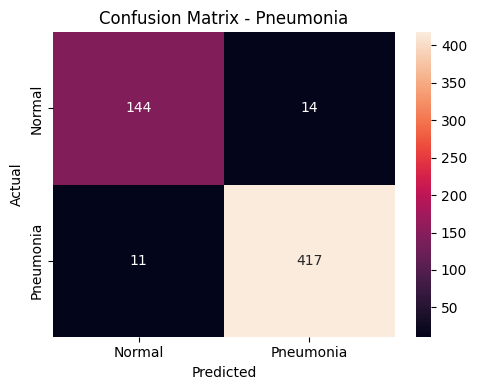

In [7]:
import torch
import torch.nn as nn
import timm
import time

from thop import profile
from datasets import load_dataset, concatenate_datasets
from torchvision.transforms import *
from torch.utils.data import DataLoader

# METRICS
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ─────────────────────────────
# DEVICE
# ─────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
print("Device:", DEVICE)

# ─────────────────────────────
# LOAD DATASET
# ─────────────────────────────
ds_raw = load_dataset("hf-vision/chest-xray-pneumonia")

full_data = concatenate_datasets([
    ds_raw["train"],
    ds_raw["validation"],
    ds_raw["test"]
])

split1 = full_data.train_test_split(
    test_size=0.2,
    seed=42,
    stratify_by_column="label"
)

train_raw = split1["train"]

split2 = split1["test"].train_test_split(
    test_size=0.5,
    seed=42,
    stratify_by_column="label"
)

val_raw = split2["train"]
test_raw = split2["test"]

print("Train:", len(train_raw), "Val:", len(val_raw), "Test:", len(test_raw))

# ─────────────────────────────
# TRANSFORMS
# ─────────────────────────────
SIZE = 224

train_tf = Compose([
    Resize((SIZE, SIZE)),
    RandomHorizontalFlip(),
    RandomRotation(10),
    ToTensor(),
    Normalize((0.5,)*3, (0.5,)*3),
])

eval_tf = Compose([
    Resize((SIZE, SIZE)),
    CenterCrop(SIZE),
    ToTensor(),
    Normalize((0.5,)*3, (0.5,)*3),
])

def train_map(batch):
    batch["pixel_values"] = [train_tf(img.convert("RGB")) for img in batch["image"]]
    return batch

def eval_map(batch):
    batch["pixel_values"] = [eval_tf(img.convert("RGB")) for img in batch["image"]]
    return batch

train_ds = train_raw.with_transform(train_map)
val_ds   = val_raw.with_transform(eval_map)
test_ds  = test_raw.with_transform(eval_map)

# ─────────────────────────────
# BACKBONES
# ─────────────────────────────
import sys

MEDVIT_DIR = r"C:\Users\hassa\OneDrive\Desktop\sem6\ANN\multimodal\MEDVIT\MedViTV2-main"
MEDFORMER_DIR = r"C:\Users\hassa\OneDrive\Desktop\sem6\ANN\multimodal\MedFormer-main"

MEDVIT_CKPT = r"C:\Users\hassa\OneDrive\Desktop\sem6\ANN\multimodal\Pretrained Models\MedViT_tiny_ISIC2018.pth"
MEDFORMER_CKPT = r"C:\Users\hassa\OneDrive\Desktop\sem6\ANN\multimodal\Pretrained Models\Medformer_tiny_BT.pth"

sys.path.insert(0, MEDVIT_DIR)
sys.path.insert(0, MEDFORMER_DIR)

from MedViT import MedViT_tiny
from models.medformer import medformer_tiny

# DeiT
deit = timm.create_model("deit_base_patch16_224", pretrained=True)
deit.head = nn.Identity()

class DeiTBackbone(nn.Module):
    def __init__(self, m):
        super().__init__()
        self.m = m
    def forward(self, x):
        x = self.m.forward_features(x)
        return x[:, 0]

# MedViT
def load_medvit():
    model = MedViT_tiny(num_classes=7)
    ckpt = torch.load(MEDVIT_CKPT, map_location="cpu")
    state = ckpt.get("model", ckpt.get("state_dict", ckpt))
    model.load_state_dict(state, strict=False)
    model.proj_head = nn.Identity()

    class Backbone(nn.Module):
        def __init__(self, m):
            super().__init__()
            self.m = m
        def forward(self, x):
            return self.m(x)

    return Backbone(model)

# MedFormer
def load_medformer():
    import argparse
    from torch.serialization import add_safe_globals
    add_safe_globals([argparse.Namespace])

    model = medformer_tiny(num_classes=4)
    ckpt = torch.load(MEDFORMER_CKPT, map_location="cpu", weights_only=False)
    state = ckpt.get("model", ckpt.get("state_dict", ckpt))
    model.load_state_dict(state, strict=False)
    model.head = nn.Identity()

    class Backbone(nn.Module):
        def __init__(self, m):
            super().__init__()
            self.m = m
        def forward(self, x):
            x = self.m.forward_features(x)
            return x.flatten(2).mean(-1)

    return Backbone(model)

# ─────────────────────────────
# FUSION MODEL
# ─────────────────────────────
class FusionModel(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        self.deit = DeiTBackbone(deit).to(DEVICE)
        self.medvit = load_medvit().to(DEVICE)
        self.medformer = load_medformer().to(DEVICE)

        # freeze backbones
        for m in [self.deit, self.medvit, self.medformer]:
            for p in m.parameters():
                p.requires_grad = False

        self.p1 = nn.Linear(768, 256)
        self.p2 = nn.Linear(384, 256)
        self.p3 = nn.Linear(256, 256)

        self.classifier = nn.Sequential(
            nn.Linear(256 * 3, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        f1 = self.p1(self.deit(x))
        f2 = self.p2(self.medvit(x))
        f3 = self.p3(self.medformer(x))

        fused = torch.cat([f1, f2, f3], dim=1)
        return self.classifier(fused)

model = FusionModel().to(DEVICE)

# ─────────────────────────────
# DATALOADER
# ─────────────────────────────
def collate(batch):
    return {
        "x": torch.stack([b["pixel_values"] for b in batch]),
        "y": torch.tensor([b["label"] for b in batch])
    }

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, collate_fn=collate)
val_loader   = DataLoader(val_ds, batch_size=16, collate_fn=collate)
test_loader  = DataLoader(test_ds, batch_size=16, collate_fn=collate)

# ─────────────────────────────
# FLOPs
# ─────────────────────────────
print("\nComputing FLOPs...")
dummy = torch.randn(1, 3, 224, 224).to(DEVICE)

f1,_ = profile(model.deit, inputs=(dummy,), verbose=False)
f2,_ = profile(model.medvit, inputs=(dummy,), verbose=False)
f3,_ = profile(model.medformer, inputs=(dummy,), verbose=False)

print("TOTAL FLOPs:", f1 + f2 + f3)

# ─────────────────────────────
# TRAINING
# ─────────────────────────────
opt = torch.optim.AdamW(
    list(model.p1.parameters()) +
    list(model.p2.parameters()) +
    list(model.p3.parameters()) +
    list(model.classifier.parameters()),
    lr=1e-4
)

loss_fn = nn.CrossEntropyLoss()

def train_epoch():
    model.train()
    total = 0
    for batch in train_loader:
        x = batch["x"].to(DEVICE)
        y = batch["y"].to(DEVICE)

        opt.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward()
        opt.step()

        total += loss.item()

    return total / len(train_loader)

def evaluate_full(loader):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            x = batch["x"].to(DEVICE)
            y = batch["y"].to(DEVICE)

            preds = model(x).argmax(1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    return all_labels, all_preds

def evaluate_acc(loader):
    y_true, y_pred = evaluate_full(loader)
    return accuracy_score(y_true, y_pred)

# ─────────────────────────────
# TRAIN LOOP
# ─────────────────────────────
start = time.time()

for epoch in range(5):
    loss = train_epoch()
    val_acc = evaluate_acc(val_loader)

    print(f"Epoch {epoch+1} | Loss {loss:.4f} | Val Acc {val_acc:.4f}")

end = time.time()

# ─────────────────────────────
# FINAL RESULTS
# ─────────────────────────────
total_time = end - start

y_true, y_pred = evaluate_full(test_loader)

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='macro')
rec  = recall_score(y_true, y_pred, average='macro')
f1   = f1_score(y_true, y_pred, average='macro')

print("\n──────── FINAL RESULTS ────────")
print(f"Training Time (s): {total_time:.2f}")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")

# ─────────────────────────────
# CONFUSION MATRIX
# ─────────────────────────────
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Normal", "Pneumonia"],
            yticklabels=["Normal", "Pneumonia"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Pneumonia")
plt.tight_layout()

plt.savefig("pneumonia_confusion_matrix.png", dpi=300)
plt.show()

## Parallel Execution

## BT Dataset Sequential

Device: cuda
Classes (9): ['adipose', 'background', 'debris', 'lymphocytes', 'mucus', 'smooth muscle', 'normal colon mucosa', 'cancer-associated stroma', 'colorectal adenocarcinoma epithelium']
Train: 89996 | Val: 10004 | Test: 7180
initialize_weights...
Trainable: 560,393 / Total: 100,195,622

--- FLOPs ---
  DeiT        : 16.86 GFLOPs
  MedViT      : 1.22 GFLOPs
  MedFormer   : 0.42 GFLOPs
  Fusion+Head : 0.0006 GFLOPs
  TOTAL       : 18.51 GFLOPs

--- Latency Benchmark (Sequential) ---
  Latency    : 70.43 ms
  Throughput : 227.2 img/s



Epoch 1/5:   0%|          | 0/5625 [00:00<?, ?it/s]C:\Users\hassa\AppData\Local\Temp\ipykernel_2884\2084857483.py:76: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return img, int(label)           # scalar label, matching original pipeline
Epoch 1/5: 100%|██████████| 5625/5625 [07:48<00:00, 12.00it/s]


Epoch 1/5 | Loss 0.3305 | Val Acc 0.9390 | Val F1 0.9391 | Time 468.7s | Throughput 192.0 img/s | TFLOPs 312.29


Epoch 2/5:   0%|          | 0/5625 [00:00<?, ?it/s]C:\Users\hassa\AppData\Local\Temp\ipykernel_2884\2084857483.py:76: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return img, int(label)           # scalar label, matching original pipeline
Epoch 2/5: 100%|██████████| 5625/5625 [07:40<00:00, 12.23it/s]


Epoch 2/5 | Loss 0.1835 | Val Acc 0.9553 | Val F1 0.9553 | Time 460.0s | Throughput 195.6 img/s | TFLOPs 312.29


...

Epoch 4/5 | Loss 0.1385 | Val Acc 0.9624 | Val F1 0.9622 | Time 459.9s | Throughput 195.7 img/s | TFLOPs 312.29


Epoch 5/5:   0%|          | 0/5625 [00:00<?, ?it/s]C:\Users\hassa\AppData\Local\Temp\ipykernel_2884\2084857483.py:76: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return img, int(label)           # scalar label, matching original pipeline
Epoch 5/5: 100%|██████████| 5625/5625 [07:39<00:00, 12.23it/s]


Epoch 5/5 | Loss 0.1272 | Val Acc 0.9642 | Val F1 0.9642 | Time 459.9s | Throughput 195.7 img/s | TFLOPs 312.29


C:\Users\hassa\AppData\Local\Temp\ipykernel_2884\2084857483.py:76: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return img, int(label)           # scalar label, matching original pipeline



      SEQUENTIAL FUSION — FINAL METRICS SUMMARY

[Model]
  FLOPs/forward  : 18.51 GFLOPs
  Latency        : 70.43 ms  (batch=16)
  Throughput     : 227.2 img/s
  Trainable      : 560,393 / 100,195,622 params

[Training]
  Total time     : 2561.77s (42.70 min)
  Avg/epoch      : 512.4s

[Per-Epoch Breakdown]
  Ep   Loss      ValAcc    ValF1     Time(s)   Img/s     TFLOPs
  --------------------------------------------------------------
  1    0.3305    0.9390    0.9391    468.7     192.0     312.29
  2    0.1835    0.9553    0.9553    460.0     195.6     312.29
  3    0.1558    0.9600    0.9597    460.0     195.6     312.29
  4    0.1385    0.9624    0.9622    459.9     195.7     312.29
  5    0.1272    0.9642    0.9642    459.9     195.7     312.29

[Test Results]
  Accuracy  : 0.8937 (89.37%)
  Precision : 0.8552
  Recall    : 0.8496
  F1 Score  : 0.8499


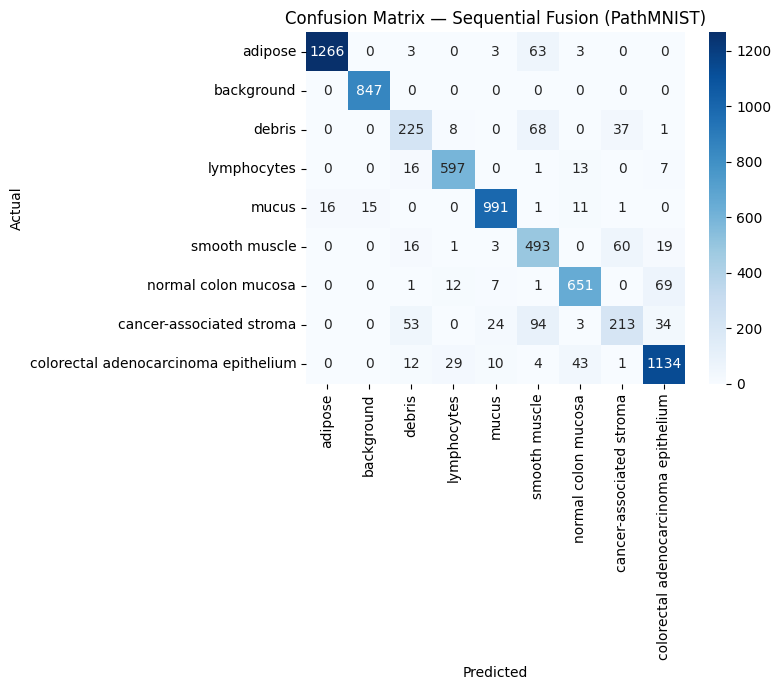

In [8]:
import os
import sys
import time
import numpy as np
import torch
import torch.nn as nn
import timm
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import Compose, Resize, ToTensor, Normalize
from thop import profile
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image as PILImage
import medmnist
from medmnist import PathMNIST, INFO

# ─────────────────────────────
# DEVICE
# ─────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
print("Device:", DEVICE)

# ─────────────────────────────
# PATHS
# ─────────────────────────────
MEDVIT_DIR    = r"C:\Users\hassa\OneDrive\Desktop\sem6\ANN\multimodal\MEDVIT\MedViTV2-main"
MEDFORMER_DIR = r"C:\Users\hassa\OneDrive\Desktop\sem6\ANN\multimodal\MedFormer-main"
PRETRAINED    = r"C:\Users\hassa\OneDrive\Desktop\sem6\ANN\multimodal\Pretrained Models"

sys.path.insert(0, MEDVIT_DIR)
sys.path.insert(0, MEDFORMER_DIR)

from MedViT import MedViT_tiny
from models.medformer import medformer_tiny
import argparse
from torch.serialization import add_safe_globals
add_safe_globals([argparse.Namespace])

# ─────────────────────────────
# DATASET CLASS
# Wraps MedMNIST split into a
# standard Dataset compatible
# with the rest of the pipeline
# ─────────────────────────────
SIZE = 224

tf = Compose([
    Resize((SIZE, SIZE)),
    ToTensor(),
    Normalize((0.5,)*3, (0.5,)*3)
])

class PathMNISTDataset(Dataset):
    """
    Thin wrapper around a MedMNIST PathMNIST split.
    Resizes 28×28 RGB tiles to SIZE×SIZE and returns
    a flat integer label (not a one-element array).
    """
    def __init__(self, split: str):
        # as_rgb=True guarantees 3-channel output
        self.ds = PathMNIST(split=split, download=True, as_rgb=True)

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, i):
        img, label = self.ds[i]          # img is a PIL Image, label is ndarray([k])
        img = tf(img)
        return img, int(label)           # scalar label, matching original pipeline


# ─────────────────────────────
# ALL TRAINING CODE INSIDE HERE
# ─────────────────────────────
if __name__ == '__main__':

    # ── PathMNIST Info ──
    info       = INFO['pathmnist']
    classes    = list(info['label'].values())   # human-readable class names
    NUM_CLASSES = len(classes)
    print(f"Classes ({NUM_CLASSES}):", classes)

    # ── Data Loading ──
    train_dataset = PathMNISTDataset(split='train')
    val_dataset   = PathMNISTDataset(split='val')
    test_dataset  = PathMNISTDataset(split='test')

    print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

    BATCH_SIZE = 16

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE, shuffle=True,
        num_workers=0, pin_memory=True,
        persistent_workers=False
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        num_workers=0, pin_memory=True,
        persistent_workers=False
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        num_workers=0, pin_memory=True,
        persistent_workers=False
    )

    # ── Backbones ──
    deit = timm.create_model("deit_base_patch16_224", pretrained=True)
    deit.head = nn.Identity()
    if hasattr(deit, "head_dist"):
        deit.head_dist = nn.Identity()

    medvit = MedViT_tiny(num_classes=7)
    medvit.proj_head = nn.Identity()
    ckpt_vit = torch.load(
        os.path.join(PRETRAINED, "MedViT_tiny_ISIC2018.pth"),
        map_location="cpu"
    )
    state_vit = ckpt_vit.get("model", ckpt_vit.get("state_dict", ckpt_vit))
    medvit.load_state_dict(state_vit, strict=False)
    medvit.eval()

    medformer = medformer_tiny(num_classes=4)
    medformer.head = nn.Identity()
    ckpt_former = torch.load(
        os.path.join(PRETRAINED, "Medformer_tiny_BT.pth"),
        map_location="cpu", weights_only=False
    )
    state_former = ckpt_former.get("model", ckpt_former.get("state_dict", ckpt_former))
    medformer.load_state_dict(state_former, strict=False)
    medformer.eval()

    # ── Backbone Wrappers ──
    class DeiTBackbone(nn.Module):
        def __init__(self):
            super().__init__()
            self.m = deit
        def forward(self, x):
            return self.m.forward_features(x)[:, 0]

    class MedViTBackbone(nn.Module):
        def __init__(self):
            super().__init__()
            self.m = medvit
        def forward(self, x):
            return self.m(x)

    class MedFormerBackbone(nn.Module):
        def __init__(self):
            super().__init__()
            self.m = medformer
        def forward(self, x):
            x = self.m.forward_features(x)
            return x.flatten(2).mean(-1)

    # ── Fusion Model ──
    class Fusion(nn.Module):
        def __init__(self):
            super().__init__()
            self.deit      = DeiTBackbone().to(DEVICE)
            self.medvit    = MedViTBackbone().to(DEVICE)
            self.medformer = MedFormerBackbone().to(DEVICE)

            self.p1 = nn.Linear(768, 256)
            self.p2 = nn.Linear(384, 256)
            self.p3 = nn.Linear(256, 256)

            self.cls = nn.Sequential(
                nn.Linear(768, 256),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(256, NUM_CLASSES)
            )

        def forward(self, x):
            f1 = self.p1(self.deit(x))
            f2 = self.p2(self.medvit(x))
            f3 = self.p3(self.medformer(x))
            return self.cls(torch.cat([f1, f2, f3], dim=1))

    model = Fusion().to(DEVICE)

    for m in [model.deit, model.medvit, model.medformer]:
        for p in m.parameters():
            p.requires_grad = False

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_p   = sum(p.numel() for p in model.parameters())
    print(f"Trainable: {trainable:,} / Total: {total_p:,}")

    # ── FLOPs ──
    dummy = torch.randn(1, 3, 224, 224).to(DEVICE)
    try:
        total_flops, _ = profile(model, inputs=(dummy,), verbose=False)
        f1_, _ = profile(model.deit,      inputs=(dummy,), verbose=False)
        f2_, _ = profile(model.medvit,    inputs=(dummy,), verbose=False)
        f3_, _ = profile(model.medformer, inputs=(dummy,), verbose=False)
        print(f"\n--- FLOPs ---")
        print(f"  DeiT        : {f1_/1e9:.2f} GFLOPs")
        print(f"  MedViT      : {f2_/1e9:.2f} GFLOPs")
        print(f"  MedFormer   : {f3_/1e9:.2f} GFLOPs")
        print(f"  Fusion+Head : {(total_flops-f1_-f2_-f3_)/1e9:.4f} GFLOPs")
        print(f"  TOTAL       : {total_flops/1e9:.2f} GFLOPs\n")
    except Exception as e:
        print(f"FLOPs error: {e}")
        total_flops = None

    # ── Latency Benchmark ──
    print("--- Latency Benchmark (Sequential) ---")
    model.eval()
    bench = torch.randn(BATCH_SIZE, 3, 224, 224).to(DEVICE)
    with torch.no_grad():
        for _ in range(3):
            _ = model(bench)
    torch.cuda.synchronize()
    lat_times = []
    with torch.no_grad():
        for _ in range(10):
            torch.cuda.synchronize()
            t0 = time.perf_counter()
            _  = model(bench)
            torch.cuda.synchronize()
            t1 = time.perf_counter()
            lat_times.append((t1-t0)*1000)
    avg_latency    = np.mean(lat_times)
    avg_throughput = BATCH_SIZE / (avg_latency / 1000)
    print(f"  Latency    : {avg_latency:.2f} ms")
    print(f"  Throughput : {avg_throughput:.1f} img/s\n")

    # ── Optimizer ──
    opt = torch.optim.AdamW(
        list(model.p1.parameters()) +
        list(model.p2.parameters()) +
        list(model.p3.parameters()) +
        list(model.cls.parameters()),
        lr=1e-4
    )
    loss_fn = nn.CrossEntropyLoss()

    # ── Evaluate Function ──
    def evaluate_full(loader):
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for x, y in loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                preds = model(x).argmax(1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(y.cpu().numpy())
        return all_labels, all_preds

    # ── Train Loop ──
    EPOCHS        = 5
    epoch_metrics = []
    total_start   = time.perf_counter()

    for e in range(EPOCHS):
        model.train()
        total_loss   = 0
        total_images = 0

        torch.cuda.synchronize()
        ep_start = time.perf_counter()

        for x, y in tqdm(train_loader, desc=f"Epoch {e+1}/{EPOCHS}"):
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            loss = loss_fn(model(x), y)
            loss.backward()
            opt.step()
            total_loss   += loss.item()
            total_images += x.size(0)

        torch.cuda.synchronize()
        ep_time    = time.perf_counter() - ep_start
        throughput = total_images / ep_time
        avg_loss   = total_loss / len(train_loader)

        val_true, val_pred = evaluate_full(val_loader)
        val_acc = accuracy_score(val_true, val_pred)
        val_f1  = f1_score(val_true, val_pred,
                           average='macro', zero_division=0)

        tflops_epoch = (
            (total_flops * len(train_loader) * 3) / 1e12
            if total_flops else float("nan")
        )

        epoch_metrics.append({
            "epoch"  : e + 1,
            "loss"   : avg_loss,
            "val_acc": val_acc,
            "val_f1" : val_f1,
            "time_s" : ep_time,
            "img_s"  : throughput,
            "tflops" : tflops_epoch,
        })

        print(
            f"Epoch {e+1}/{EPOCHS} | "
            f"Loss {avg_loss:.4f} | "
            f"Val Acc {val_acc:.4f} | "
            f"Val F1 {val_f1:.4f} | "
            f"Time {ep_time:.1f}s | "
            f"Throughput {throughput:.1f} img/s | "
            f"TFLOPs {tflops_epoch:.2f}"
        )

    total_time = time.perf_counter() - total_start

    # ── Final Test Evaluation ──
    y_true, y_pred = evaluate_full(test_loader)

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true, y_pred,    average='macro', zero_division=0)
    f1   = f1_score(y_true, y_pred,        average='macro', zero_division=0)

    # ── Final Summary ──
    print("\n" + "="*70)
    print("      SEQUENTIAL FUSION — FINAL METRICS SUMMARY")
    print("="*70)
    print(f"\n[Model]")
    if total_flops:
        print(f"  FLOPs/forward  : {total_flops/1e9:.2f} GFLOPs")
    print(f"  Latency        : {avg_latency:.2f} ms  (batch={BATCH_SIZE})")
    print(f"  Throughput     : {avg_throughput:.1f} img/s")
    print(f"  Trainable      : {trainable:,} / {total_p:,} params")
    print(f"\n[Training]")
    print(f"  Total time     : {total_time:.2f}s ({total_time/60:.2f} min)")
    print(f"  Avg/epoch      : {total_time/EPOCHS:.1f}s")
    print(f"\n[Per-Epoch Breakdown]")
    print(f"  {'Ep':<4} {'Loss':<9} {'ValAcc':<9} {'ValF1':<9} "
          f"{'Time(s)':<9} {'Img/s':<9} {'TFLOPs'}")
    print(f"  {'-'*62}")
    for m in epoch_metrics:
        print(
            f"  {m['epoch']:<4} "
            f"{m['loss']:<9.4f} "
            f"{m['val_acc']:<9.4f} "
            f"{m['val_f1']:<9.4f} "
            f"{m['time_s']:<9.1f} "
            f"{m['img_s']:<9.1f} "
            f"{m['tflops']:.2f}"
        )
    print(f"\n[Test Results]")
    print(f"  Accuracy  : {acc:.4f} ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print("="*70)

    # ── Confusion Matrix ──
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 7))
    sns.heatmap(
        cm, annot=True, fmt="d",
        xticklabels=classes,
        yticklabels=classes,
        cmap="Blues"
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix — Sequential Fusion (PathMNIST)")
    plt.tight_layout()
    plt.savefig("confusion_matrix_sequential.png", dpi=150)
    plt.show()

## BT Dataset Parallel

In [9]:
import os
import sys
import time
import numpy as np
import torch
import torch.nn as nn
import timm
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix
)
from torchvision.transforms import Compose, Resize, ToTensor, Normalize
from thop import profile
from tqdm import tqdm
import medmnist
from medmnist import PathMNIST, INFO

# ─────────────────────────────
# DEVICE
# ─────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
print("Device:", DEVICE)

# ─────────────────────────────
# PATHS
# ─────────────────────────────
MEDVIT_DIR    = r"C:\Users\hassa\OneDrive\Desktop\sem6\ANN\multimodal\MEDVIT\MedViTV2-main"
MEDFORMER_DIR = r"C:\Users\hassa\OneDrive\Desktop\sem6\ANN\multimodal\MedFormer-main"
PRETRAINED    = r"C:\Users\hassa\OneDrive\Desktop\sem6\ANN\multimodal\Pretrained Models"

sys.path.insert(0, MEDVIT_DIR)
sys.path.insert(0, MEDFORMER_DIR)

from MedViT import MedViT_tiny
from models.medformer import medformer_tiny

# ─────────────────────────────
# PathMNIST INFO
# ─────────────────────────────
info        = INFO['pathmnist']
classes     = list(info['label'].values())   # 9 colon-histology class names
NUM_CLASSES = len(classes)
print(f"Classes ({NUM_CLASSES}):", classes)

# ─────────────────────────────
# DATASET & LOADERS
# ─────────────────────────────
SIZE = 224

tf_train = Compose([
    Resize((SIZE, SIZE)),
    ToTensor(),
    Normalize((0.5,)*3, (0.5,)*3)
])

tf_eval = Compose([
    Resize((SIZE, SIZE)),
    ToTensor(),
    Normalize((0.5,)*3, (0.5,)*3)
])

class PathMNISTDataset(Dataset):
    """
    Thin wrapper around a MedMNIST PathMNIST split.
    Resizes 28×28 RGB tiles to SIZE×SIZE and returns
    a flat integer label (not a one-element array).
    """
    def __init__(self, split: str, transform):
        self.ds = PathMNIST(split=split, download=True, as_rgb=True)
        self.tf = transform

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, i):
        img, label = self.ds[i]     # img: PIL Image, label: ndarray([k])
        return self.tf(img), int(label)

BATCH_SIZE = 16

train_loader = DataLoader(
    PathMNISTDataset(split='train', transform=tf_train),
    batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=True,
    persistent_workers=False
)
val_loader = DataLoader(
    PathMNISTDataset(split='val', transform=tf_eval),
    batch_size=BATCH_SIZE,
    num_workers=0, pin_memory=True,
    persistent_workers=False
)
test_loader = DataLoader(
    PathMNISTDataset(split='test', transform=tf_eval),
    batch_size=BATCH_SIZE,
    num_workers=0, pin_memory=True,
    persistent_workers=False
)

print(f"Train: {len(train_loader.dataset)} | Val: {len(val_loader.dataset)} | Test: {len(test_loader.dataset)}")

# ─────────────────────────────
# BACKBONES
# ─────────────────────────────

# ── DeiT ──
deit = timm.create_model("deit_base_patch16_224", pretrained=True)
deit.head = nn.Identity()
if hasattr(deit, "head_dist"):
    deit.head_dist = nn.Identity()

# ── MedViT ──
medvit = MedViT_tiny(num_classes=7)
ckpt_vit = torch.load(
    os.path.join(PRETRAINED, "MedViT_tiny_ISIC2018.pth"),
    map_location="cpu"
)
state_vit = ckpt_vit.get("model", ckpt_vit.get("state_dict", ckpt_vit))
medvit.load_state_dict(state_vit, strict=False)
medvit.proj_head = nn.Identity()
medvit.eval()
print("MedViT weights loaded")

# ── MedFormer ──
import argparse
from torch.serialization import add_safe_globals
add_safe_globals([argparse.Namespace])

medformer = medformer_tiny(num_classes=4)
ckpt_former = torch.load(
    os.path.join(PRETRAINED, "Medformer_tiny_BT.pth"),
    map_location="cpu",
    weights_only=False
)
state_former = ckpt_former.get("model", ckpt_former.get("state_dict", ckpt_former))
medformer.load_state_dict(state_former, strict=False)
medformer.head = nn.Identity()
medformer.eval()
print("MedFormer weights loaded")

# ─────────────────────────────
# BACKBONE WRAPPERS
# ─────────────────────────────
class DeiTBackbone(nn.Module):
    def __init__(self, m):
        super().__init__()
        self.m = m
    def forward(self, x):
        return self.m.forward_features(x)[:, 0]  # CLS token [B, 768]

class MedViTBackbone(nn.Module):
    def __init__(self, m):
        super().__init__()
        self.m = m
    def forward(self, x):
        return self.m(x)

class MedFormerBackbone(nn.Module):
    def __init__(self, m):
        super().__init__()
        self.m = m
    def forward(self, x):
        x = self.m.forward_features(x)
        return x.flatten(2).mean(-1)

# ─────────────────────────────
# VERIFY DIMS
# ─────────────────────────────
print("\n--- Verifying backbone output dimensions ---")
_dummy = torch.randn(2, 3, 224, 224)

with torch.no_grad():
    deit_dim      = DeiTBackbone(deit)(_dummy).shape[-1]
    medvit_dim    = MedViTBackbone(medvit)(_dummy).shape[-1]
    medformer_dim = MedFormerBackbone(medformer)(_dummy).shape[-1]

print(f"  DeiT      → {deit_dim}")
print(f"  MedViT    → {medvit_dim}")
print(f"  MedFormer → {medformer_dim}")
print("--------------------------------------------\n")

COMMON_DIM = 256
FUSED_DIM  = COMMON_DIM * 3

# ─────────────────────────────
# STREAM FUSION MODEL
# ─────────────────────────────
class StreamFusionModel(nn.Module):
    def __init__(self, num_classes, deit_dim, medvit_dim, medformer_dim):
        super().__init__()

        # Backbones
        self.deit      = DeiTBackbone(deit)
        self.medvit    = MedViTBackbone(medvit)
        self.medformer = MedFormerBackbone(medformer)

        # Freeze all backbone parameters
        for backbone in [self.deit, self.medvit, self.medformer]:
            for p in backbone.parameters():
                p.requires_grad = False

        # Verified projection layers
        self.p1 = nn.Linear(deit_dim,      COMMON_DIM)
        self.p2 = nn.Linear(medvit_dim,    COMMON_DIM)
        self.p3 = nn.Linear(medformer_dim, COMMON_DIM)

        # Classification head
        self.classifier = nn.Sequential(
            nn.LayerNorm(FUSED_DIM),
            nn.Linear(FUSED_DIM, 512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

        # One dedicated stream per backbone
        self.s1 = torch.cuda.Stream()
        self.s2 = torch.cuda.Stream()
        self.s3 = torch.cuda.Stream()

    def forward(self, x):
        # Force backbones to eval regardless of model.train()
        # Required: frozen params + BatchNorm stability
        self.deit.m.eval()
        self.medvit.m.eval()
        self.medformer.m.eval()

        f1 = f2 = f3 = None

        # All three backbone forward passes launched concurrently
        # No microbatch loop — full batch through all streams at once
        with torch.cuda.stream(self.s1):
            f1 = self.p1(self.deit(x))

        with torch.cuda.stream(self.s2):
            f2 = self.p2(self.medvit(x))

        with torch.cuda.stream(self.s3):
            f3 = self.p3(self.medformer(x))

        # Wait for all three streams before fusion
        torch.cuda.current_stream().wait_stream(self.s1)
        torch.cuda.current_stream().wait_stream(self.s2)
        torch.cuda.current_stream().wait_stream(self.s3)

        fused = torch.cat([f1, f2, f3], dim=1)
        return self.classifier(fused)

model = StreamFusionModel(
    num_classes=NUM_CLASSES,
    deit_dim=deit_dim,
    medvit_dim=medvit_dim,
    medformer_dim=medformer_dim
).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_p   = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / Total: {total_p:,}\n")

# ─────────────────────────────
# FLOPs
# ─────────────────────────────
print("--- FLOPs Analysis ---")
dummy_gpu = torch.randn(1, 3, 224, 224).to(DEVICE)

try:
    total_flops, _ = profile(model, inputs=(dummy_gpu,), verbose=False)
    f1_, _ = profile(model.deit,      inputs=(dummy_gpu,), verbose=False)
    f2_, _ = profile(model.medvit,    inputs=(dummy_gpu,), verbose=False)
    f3_, _ = profile(model.medformer, inputs=(dummy_gpu,), verbose=False)

    print(f"  DeiT        : {f1_/1e9:.2f} GFLOPs")
    print(f"  MedViT      : {f2_/1e9:.2f} GFLOPs")
    print(f"  MedFormer   : {f3_/1e9:.2f} GFLOPs")
    print(f"  Fusion+Head : {(total_flops-f1_-f2_-f3_)/1e9:.4f} GFLOPs")
    print(f"  TOTAL       : {total_flops/1e9:.2f} GFLOPs")
except Exception as e:
    print(f"FLOPs error: {e}")
    total_flops = None
print("----------------------\n")

# ─────────────────────────────
# LATENCY BENCHMARK
# ─────────────────────────────
print("--- Latency Benchmark (Stream Model) ---")
model.eval()
bench = torch.randn(BATCH_SIZE, 3, 224, 224).to(DEVICE)

with torch.no_grad():
    for _ in range(3):
        _ = model(bench)

torch.cuda.synchronize()
lat_times = []

with torch.no_grad():
    for _ in range(10):
        torch.cuda.synchronize()
        t0 = time.perf_counter()
        _  = model(bench)
        torch.cuda.synchronize()
        t1 = time.perf_counter()
        lat_times.append((t1 - t0) * 1000)

avg_latency    = np.mean(lat_times)
avg_throughput = BATCH_SIZE / (avg_latency / 1000)
print(f"  Avg latency  : {avg_latency:.2f} ms  (batch={BATCH_SIZE})")
print(f"  Throughput   : {avg_throughput:.1f} images/sec")
print("----------------------------------------\n")

# ─────────────────────────────
# OPTIMIZER — unfrozen only
# ─────────────────────────────
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)
loss_fn = nn.CrossEntropyLoss()

# ─────────────────────────────
# EVALUATE FUNCTION
# ─────────────────────────────
def evaluate(loader):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            p = model(x).argmax(1).cpu().numpy()
            all_preds.append(p)
            all_labels.append(y.numpy())

    y_true = np.concatenate(all_labels)
    y_pred = np.concatenate(all_preds)

    return {
        "accuracy" : accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall"   : recall_score(y_true, y_pred,    average="macro", zero_division=0),
        "f1"       : f1_score(y_true, y_pred,        average="macro", zero_division=0),
        "confusion": confusion_matrix(y_true, y_pred),
    }

# ─────────────────────────────
# TRAIN LOOP WITH FULL METRICS
# ─────────────────────────────
EPOCHS        = 5
epoch_metrics = []
total_start   = time.perf_counter()

for epoch in range(EPOCHS):
    model.train()
    total_loss   = 0
    total_images = 0

    torch.cuda.synchronize()
    ep_start = time.perf_counter()

    for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward()
        optimizer.step()

        total_loss   += loss.item()
        total_images += x.size(0)

    torch.cuda.synchronize()
    ep_time    = time.perf_counter() - ep_start
    throughput = total_images / ep_time
    avg_loss   = total_loss / len(train_loader)

    val_m = evaluate(val_loader)

    tflops_epoch = (
        (total_flops * len(train_loader) * 3) / 1e12
        if total_flops else float("nan")
    )

    epoch_metrics.append({
        "epoch"  : epoch + 1,
        "loss"   : avg_loss,
        "val_acc": val_m["accuracy"],
        "val_f1" : val_m["f1"],
        "time_s" : ep_time,
        "img_s"  : throughput,
        "tflops" : tflops_epoch,
    })

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Loss {avg_loss:.4f} | "
        f"Val Acc {val_m['accuracy']:.4f} | "
        f"Val F1 {val_m['f1']:.4f} | "
        f"Time {ep_time:.1f}s | "
        f"Throughput {throughput:.1f} img/s | "
        f"TFLOPs {tflops_epoch:.2f}"
    )

total_time = time.perf_counter() - total_start

# ─────────────────────────────
# TEST EVALUATION
# ─────────────────────────────
test_m = evaluate(test_loader)

# ─────────────────────────────
# FINAL SUMMARY
# ─────────────────────────────
print("\n" + "="*70)
print("          STREAM FUSION — FINAL METRICS SUMMARY")
print("="*70)

print(f"\n[Model]")
if total_flops:
    print(f"  FLOPs/forward  : {total_flops/1e9:.2f} GFLOPs")
print(f"  Latency        : {avg_latency:.2f} ms  (batch={BATCH_SIZE})")
print(f"  Throughput     : {avg_throughput:.1f} img/s")
print(f"  Trainable      : {trainable:,} / {total_p:,} params")

print(f"\n[Training]")
print(f"  Total time     : {total_time:.2f}s ({total_time/60:.2f} min)")
print(f"  Avg/epoch      : {total_time/EPOCHS:.1f}s")

print(f"\n[Per-Epoch Breakdown]")
print(f"  {'Ep':<4} {'Loss':<9} {'ValAcc':<9} {'ValF1':<9} {'Time(s)':<9} {'Img/s':<9} {'TFLOPs'}")
print(f"  {'-'*62}")
for m in epoch_metrics:
    print(
        f"  {m['epoch']:<4} "
        f"{m['loss']:<9.4f} "
        f"{m['val_acc']:<9.4f} "
        f"{m['val_f1']:<9.4f} "
        f"{m['time_s']:<9.1f} "
        f"{m['img_s']:<9.1f} "
        f"{m['tflops']:.2f}"
    )

print(f"\n[Test Results]")
print(f"  Accuracy  : {test_m['accuracy']:.4f} ({test_m['accuracy']*100:.2f}%)")
print(f"  Precision : {test_m['precision']:.4f}")
print(f"  Recall    : {test_m['recall']:.4f}")
print(f"  F1 Score  : {test_m['f1']:.4f}")

print(f"\n[Confusion Matrix]")
print(test_m["confusion"])

# ─────────────────────────────
# PDC COMPARISON
# ─────────────────────────────
SEQ_TIME       = 2561.77   # your measured sequential time
SEQ_THROUGHPUT = 227.2    # your measured sequential throughput
NUM_STREAMS    = 3

speedup    = SEQ_TIME / total_time
efficiency = (speedup / NUM_STREAMS) * 100

print(f"\n[PDC Comparison]")
print(f"  Sequential time     : {SEQ_TIME:.2f}s")
print(f"  Stream parallel time: {total_time:.2f}s")
print(f"  Speedup (S)         : {speedup:.3f}x")
print(f"  Efficiency (E)      : {efficiency:.2f}%")
print(f"  Sequential tput     : {SEQ_THROUGHPUT:.1f} img/s")
print(f"  Stream tput         : {avg_throughput:.1f} img/s")
print(f"  Throughput gain     : {avg_throughput/SEQ_THROUGHPUT:.3f}x")
print("="*70)

Device: cuda
Classes (9): ['adipose', 'background', 'debris', 'lymphocytes', 'mucus', 'smooth muscle', 'normal colon mucosa', 'cancer-associated stroma', 'colorectal adenocarcinoma epithelium']
Train: 89996 | Val: 10004 | Test: 7180
initialize_weights...
MedViT weights loaded
MedFormer weights loaded

--- Verifying backbone output dimensions ---
  DeiT      → 768
  MedViT    → 384
  MedFormer → 256
--------------------------------------------

Trainable: 761,097 / Total: 100,396,326

--- FLOPs Analysis ---
  DeiT        : 16.86 GFLOPs
  MedViT      : 1.22 GFLOPs
  MedFormer   : 0.42 GFLOPs
  Fusion+Head : 0.0008 GFLOPs
  TOTAL       : 18.51 GFLOPs
----------------------

--- Latency Benchmark (Stream Model) ---
  Avg latency  : 70.46 ms  (batch=16)
  Throughput   : 227.1 images/sec
----------------------------------------



Epoch 1/5:   0%|          | 0/5625 [00:00<?, ?it/s]C:\Users\hassa\AppData\Local\Temp\ipykernel_2884\2222001237.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return self.tf(img), int(label)
Epoch 1/5: 100%|██████████| 5625/5625 [07:36<00:00, 12.31it/s]


Epoch 1/5 | Loss 0.4349 | Val Acc 0.9249 | Val F1 0.9245 | Time 456.8s | Throughput 197.0 img/s | TFLOPs 312.30


Epoch 2/5:   0%|          | 0/5625 [00:00<?, ?it/s]C:\Users\hassa\AppData\Local\Temp\ipykernel_2884\2222001237.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return self.tf(img), int(label)
Epoch 2/5: 100%|██████████| 5625/5625 [07:37<00:00, 12.30it/s]


Epoch 2/5 | Loss 0.2351 | Val Acc 0.9321 | Val F1 0.9314 | Time 457.4s | Throughput 196.7 img/s | TFLOPs 312.30


...

Epoch 4/5 | Loss 0.1788 | Val Acc 0.9479 | Val F1 0.9483 | Time 460.8s | Throughput 195.3 img/s | TFLOPs 312.30


Epoch 5/5:   0%|          | 0/5625 [00:00<?, ?it/s]C:\Users\hassa\AppData\Local\Temp\ipykernel_2884\2222001237.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return self.tf(img), int(label)
Epoch 5/5: 100%|██████████| 5625/5625 [07:37<00:00, 12.30it/s]


Epoch 5/5 | Loss 0.1626 | Val Acc 0.9447 | Val F1 0.9434 | Time 457.2s | Throughput 196.9 img/s | TFLOPs 312.30


C:\Users\hassa\AppData\Local\Temp\ipykernel_2884\2222001237.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return self.tf(img), int(label)



          STREAM FUSION — FINAL METRICS SUMMARY

[Model]
  FLOPs/forward  : 18.51 GFLOPs
  Latency        : 70.46 ms  (batch=16)
  Throughput     : 227.1 img/s
  Trainable      : 761,097 / 100,396,326 params

[Training]
  Total time     : 2540.61s (42.34 min)
  Avg/epoch      : 508.1s

[Per-Epoch Breakdown]
  Ep   Loss      ValAcc    ValF1     Time(s)   Img/s     TFLOPs
  --------------------------------------------------------------
  1    0.4349    0.9249    0.9245    456.8     197.0     312.30
  2    0.2351    0.9321    0.9314    457.4     196.7     312.30
  3    0.1995    0.9376    0.9383    457.2     196.8     312.30
  4    0.1788    0.9479    0.9483    460.8     195.3     312.30
  5    0.1626    0.9447    0.9434    457.2     196.9     312.30

[Test Results]
  Accuracy  : 0.8748 (87.48%)
  Precision : 0.8447
  Recall    : 0.8432
  F1 Score  : 0.8321

[Confusion Matrix]
[[1234    0    0    0    6   94    4    0    0]
 [   0  847    0    0    0    0    0    0    0]
 [   0    0  295

## ABLATION STUDY

## PATHMNIST

In [1]:
import torch
import torch.nn as nn
import timm
import sys
import time
import numpy as np

from torch.utils.data import DataLoader
from torchvision import transforms

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from medmnist import PathMNIST, DermaMNIST, OCTMNIST, PneumoniaMNIST, ChestMNIST

# ---------------------------
# CONFIG
# ---------------------------
DATASET_NAME = "pathmnist"   # 👈 ONLY CHANGE THIS

BATCH_SIZE = 32
EPOCHS = 5
LR = 1e-4
IMG_SIZE = 224

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ---------------------------
# DATASET MAP
# ---------------------------
dataset_map = {
    "pathmnist": PathMNIST,
    "dermamnist": DermaMNIST,
    "octmnist": OCTMNIST,
    "pneumoniamnist": PneumoniaMNIST,
    "chestmnist": ChestMNIST,
}

num_classes_map = {
    "pathmnist": 9,
    "dermamnist": 7,
    "octmnist": 4,
    "pneumoniamnist": 2,
    "chestmnist": 14,
}

DatasetClass = dataset_map[DATASET_NAME]
NUM_CLASSES = num_classes_map[DATASET_NAME]

# ChestMNIST is multilabel (ignore for now unless you want BCE version)
assert DATASET_NAME != "chestmnist", "ChestMNIST needs multilabel setup"

# ---------------------------
# TRANSFORMS
# ---------------------------
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

# ---------------------------
# LOAD DATASET
# ---------------------------
train_ds = DatasetClass(split="train", transform=transform, download=True)
val_ds   = DatasetClass(split="val", transform=transform, download=True)
test_ds  = DatasetClass(split="test", transform=transform, download=True)

print("Train:", len(train_ds), "Val:", len(val_ds), "Test:", len(test_ds))

# ---------------------------
# DATALOADER
# ---------------------------
def collate(batch):
    x = torch.stack([b[0] for b in batch])
    y = torch.tensor([b[1] for b in batch]).squeeze().long()
    return x, y

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)

# ---------------------------
# BACKBONES
# ---------------------------
MEDVIT_DIR = r"C:\Users\hassa\OneDrive\Desktop\sem6\ANN\multimodal\MEDVIT\MedViTV2-main"
MEDFORMER_DIR = r"C:\Users\hassa\OneDrive\Desktop\sem6\ANN\multimodal\MedFormer-main"

MEDVIT_CKPT = r"C:\Users\hassa\OneDrive\Desktop\sem6\ANN\multimodal\Pretrained Models\MedViT_tiny_ISIC2018.pth"
MEDFORMER_CKPT = r"C:\Users\hassa\OneDrive\Desktop\sem6\ANN\multimodal\Pretrained Models\Medformer_tiny_BT.pth"

sys.path.insert(0, MEDVIT_DIR)
sys.path.insert(0, MEDFORMER_DIR)

from MedViT import MedViT_tiny
from models.medformer import medformer_tiny

# ---------------------------
# DeiT
# ---------------------------
deit = timm.create_model("deit_base_patch16_224", pretrained=True)
deit.head = nn.Identity()

class DeiTBackbone(nn.Module):
    def __init__(self, m):
        super().__init__()
        self.m = m

    def forward(self, x):
        x = self.m.forward_features(x)
        return x[:, 0]

# ---------------------------
# MedViT
# ---------------------------
def load_medvit():
    model = MedViT_tiny(num_classes=7)
    ckpt = torch.load(MEDVIT_CKPT, map_location="cpu")
    state = ckpt.get("model", ckpt.get("state_dict", ckpt))
    model.load_state_dict(state, strict=False)
    model.proj_head = nn.Identity()

    class Backbone(nn.Module):
        def __init__(self, m):
            super().__init__()
            self.m = m
        def forward(self, x):
            return self.m(x)

    return Backbone(model)

# ---------------------------
# MedFormer
# ---------------------------
def load_medformer():
    import argparse
    from torch.serialization import add_safe_globals
    add_safe_globals([argparse.Namespace])

    model = medformer_tiny(num_classes=4)
    ckpt = torch.load(MEDFORMER_CKPT, map_location="cpu", weights_only=False)
    state = ckpt.get("model", ckpt.get("state_dict", ckpt))
    model.load_state_dict(state, strict=False)
    model.head = nn.Identity()

    class Backbone(nn.Module):
        def __init__(self, m):
            super().__init__()
            self.m = m

        def forward(self, x):
            x = self.m.forward_features(x)
            return x.flatten(2).mean(-1)

    return Backbone(model)

# ---------------------------
# FUSION MODEL (YOUR ARCHITECTURE)
# ---------------------------
class FusionModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.deit = DeiTBackbone(deit).to(DEVICE)
        self.medvit = load_medvit().to(DEVICE)
        self.medformer = load_medformer().to(DEVICE)

        # freeze
        for m in [self.deit, self.medvit, self.medformer]:
            for p in m.parameters():
                p.requires_grad = False

        self.p1 = nn.Linear(768, 256)
        self.p2 = nn.Linear(384, 256)
        self.p3 = nn.Linear(256, 256)

        self.classifier = nn.Sequential(
            nn.Linear(256 * 3, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        f1 = self.p1(self.deit(x))
        f2 = self.p2(self.medvit(x))
        f3 = self.p3(self.medformer(x))

        fused = torch.cat([f1, f2, f3], dim=1)
        return self.classifier(fused)

model = FusionModel(NUM_CLASSES).to(DEVICE)

# ---------------------------
# OPTIMIZER + LOSS
# ---------------------------
optimizer = torch.optim.AdamW(
    list(model.p1.parameters()) +
    list(model.p2.parameters()) +
    list(model.p3.parameters()) +
    list(model.classifier.parameters()),
    lr=LR
)

loss_fn = nn.CrossEntropyLoss()

# ---------------------------
# TRAIN STEP
# ---------------------------
def train_epoch():
    model.train()
    total_loss = 0

    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

# ---------------------------
# EVAL
# ---------------------------
def evaluate(loader):
    model.eval()
    preds, labels = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            out = model(x)

            p = out.argmax(1).cpu().numpy()

            preds.append(p)
            labels.append(y.numpy())

    return np.concatenate(labels), np.concatenate(preds)

def metrics(loader):
    y, p = evaluate(loader)

    return (
        accuracy_score(y, p),
        precision_score(y, p, average="macro"),
        recall_score(y, p, average="macro"),
        f1_score(y, p, average="macro"),
    )

# ---------------------------
# TRAIN LOOP
# ---------------------------
start = time.time()

for epoch in range(EPOCHS):
    loss = train_epoch()
    val_acc, _, _, _ = metrics(val_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss {loss:.4f} | Val Acc {val_acc:.4f}")

end = time.time()

# ---------------------------
# FINAL RESULTS
# ---------------------------
acc, prec, rec, f1 = metrics(test_loader)

print("\n──────── FINAL RESULTS ────────")
print("Dataset:", DATASET_NAME)
print(f"Time     : {end-start:.2f}s")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")

Device: cuda


100%|██████████| 206M/206M [01:05<00:00, 3.16MB/s] 


Train: 89996 Val: 10004 Test: 7180


initialize_weights...


C:\Users\hassa\AppData\Local\Temp\ipykernel_17464\123751860.py:77: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  y = torch.tensor([b[1] for b in batch]).squeeze().long()


Epoch 1/5 | Loss 0.5096 | Val Acc 0.8744
Epoch 2/5 | Loss 0.3468 | Val Acc 0.8879
Epoch 3/5 | Loss 0.3091 | Val Acc 0.9016
Epoch 4/5 | Loss 0.2893 | Val Acc 0.8932
Epoch 5/5 | Loss 0.2749 | Val Acc 0.9052

──────── FINAL RESULTS ────────
Dataset: pathmnist
Time     : 2597.08s
Accuracy : 0.8575
Precision: 0.8123
Recall   : 0.8313
F1 Score : 0.8168


## PneumoniaMNIST

In [4]:
import torch
import torch.nn as nn
import timm
import sys
import time
import numpy as np

from torch.utils.data import DataLoader
from torchvision import transforms

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from medmnist import PathMNIST, DermaMNIST, OCTMNIST, PneumoniaMNIST, ChestMNIST

# ---------------------------
# CONFIG
# ---------------------------
DATASET_NAME = "pneumoniamnist"   # 👈 ONLY CHANGE THIS

BATCH_SIZE = 32
EPOCHS = 5
LR = 1e-4
IMG_SIZE = 224

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ---------------------------
# DATASET MAP
# ---------------------------
dataset_map = {
    "pathmnist": PathMNIST,
    "dermamnist": DermaMNIST,
    "octmnist": OCTMNIST,
    "pneumoniamnist": PneumoniaMNIST,
    "chestmnist": ChestMNIST,
}

num_classes_map = {
    "pathmnist": 9,
    "dermamnist": 7,
    "octmnist": 4,
    "pneumoniamnist": 2,
    "chestmnist": 14,
}

norm_stats = {
    "pathmnist"    : ([0.7405, 0.5330, 0.7058], [0.1237, 0.1751, 0.1044]),
    "dermamnist"   : ([0.7631, 0.5381, 0.5614], [0.1366, 0.1543, 0.1692]),
    "octmnist"     : ([0.1889, 0.1889, 0.1889], [0.1963, 0.1963, 0.1963]),
    "pneumoniamnist": ([0.5720, 0.5720, 0.5720], [0.1686, 0.1686, 0.1686]),
}



DatasetClass = dataset_map[DATASET_NAME]
NUM_CLASSES = num_classes_map[DATASET_NAME]

# ChestMNIST is multilabel (ignore for now unless you want BCE version)
assert DATASET_NAME != "chestmnist", "ChestMNIST needs multilabel setup"

# ---------------------------
# TRANSFORMS
# ---------------------------
mean, std = norm_stats[DATASET_NAME]

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# ---------------------------
# LOAD DATASET
# ---------------------------
train_ds = DatasetClass(split="train", transform=transform, download=True)
val_ds   = DatasetClass(split="val", transform=transform, download=True)
test_ds  = DatasetClass(split="test", transform=transform, download=True)

print("Train:", len(train_ds), "Val:", len(val_ds), "Test:", len(test_ds))

# ---------------------------
# DATALOADER
# ---------------------------
def collate(batch):
    x = torch.stack([b[0] for b in batch])
    y = torch.tensor([b[1] for b in batch]).squeeze().long()
    return x, y

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)

# ---------------------------
# BACKBONES
# ---------------------------
MEDVIT_DIR = r"C:\Users\hassa\OneDrive\Desktop\sem6\ANN\multimodal\MEDVIT\MedViTV2-main"
MEDFORMER_DIR = r"C:\Users\hassa\OneDrive\Desktop\sem6\ANN\multimodal\MedFormer-main"

MEDVIT_CKPT = r"C:\Users\hassa\OneDrive\Desktop\sem6\ANN\multimodal\Pretrained Models\MedViT_tiny_ISIC2018.pth"
MEDFORMER_CKPT = r"C:\Users\hassa\OneDrive\Desktop\sem6\ANN\multimodal\Pretrained Models\Medformer_tiny_BT.pth"

sys.path.insert(0, MEDVIT_DIR)
sys.path.insert(0, MEDFORMER_DIR)

from MedViT import MedViT_tiny
from models.medformer import medformer_tiny

# ---------------------------
# DeiT
# ---------------------------
deit = timm.create_model("deit_base_patch16_224", pretrained=True)
deit.head = nn.Identity()

class DeiTBackbone(nn.Module):
    def __init__(self, m):
        super().__init__()
        self.m = m

    def forward(self, x):
        x = self.m.forward_features(x)
        return x[:, 0]

# ---------------------------
# MedViT
# ---------------------------
def load_medvit():
    model = MedViT_tiny(num_classes=7)
    ckpt = torch.load(MEDVIT_CKPT, map_location="cpu")
    state = ckpt.get("model", ckpt.get("state_dict", ckpt))
    model.load_state_dict(state, strict=False)
    model.proj_head = nn.Identity()

    class Backbone(nn.Module):
        def __init__(self, m):
            super().__init__()
            self.m = m
        def forward(self, x):
            return self.m(x)

    return Backbone(model)

# ---------------------------
# MedFormer
# ---------------------------
def load_medformer():
    import argparse
    from torch.serialization import add_safe_globals
    add_safe_globals([argparse.Namespace])

    model = medformer_tiny(num_classes=4)
    ckpt = torch.load(MEDFORMER_CKPT, map_location="cpu", weights_only=False)
    state = ckpt.get("model", ckpt.get("state_dict", ckpt))
    model.load_state_dict(state, strict=False)
    model.head = nn.Identity()

    class Backbone(nn.Module):
        def __init__(self, m):
            super().__init__()
            self.m = m

        def forward(self, x):
            x = self.m.forward_features(x)
            return x.flatten(2).mean(-1)

    return Backbone(model)

# ---------------------------
# FUSION MODEL (YOUR ARCHITECTURE)
# ---------------------------
class FusionModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.deit = DeiTBackbone(deit).to(DEVICE)
        self.medvit = load_medvit().to(DEVICE)
        self.medformer = load_medformer().to(DEVICE)

        # freeze
        for m in [self.deit, self.medvit, self.medformer]:
            for p in m.parameters():
                p.requires_grad = False

        self.p1 = nn.Linear(768, 256)
        self.p2 = nn.Linear(384, 256)
        self.p3 = nn.Linear(256, 256)

        self.classifier = nn.Sequential(
            nn.Linear(256 * 3, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        f1 = self.p1(self.deit(x))
        f2 = self.p2(self.medvit(x))
        f3 = self.p3(self.medformer(x))

        fused = torch.cat([f1, f2, f3], dim=1)
        return self.classifier(fused)

model = FusionModel(NUM_CLASSES).to(DEVICE)

# ---------------------------
# OPTIMIZER + LOSS
# ---------------------------
optimizer = torch.optim.AdamW(
    list(model.p1.parameters()) +
    list(model.p2.parameters()) +
    list(model.p3.parameters()) +
    list(model.classifier.parameters()),
    lr=LR
)

loss_fn = nn.CrossEntropyLoss()

# ---------------------------
# TRAIN STEP
# ---------------------------
def train_epoch():
    model.train()
    total_loss = 0

    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

# ---------------------------
# EVAL
# ---------------------------
def evaluate(loader):
    model.eval()
    preds, labels = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            out = model(x)

            p = out.argmax(1).cpu().numpy()

            preds.append(p)
            labels.append(y.numpy())

    return np.concatenate(labels), np.concatenate(preds)

def metrics(loader):
    y, p = evaluate(loader)

    return (
        accuracy_score(y, p),
        precision_score(y, p, average="macro"),
        recall_score(y, p, average="macro"),
        f1_score(y, p, average="macro"),
    )

# ---------------------------
# TRAIN LOOP
# ---------------------------
start = time.time()

for epoch in range(EPOCHS):
    loss = train_epoch()
    val_acc, _, _, _ = metrics(val_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss {loss:.4f} | Val Acc {val_acc:.4f}")

end = time.time()

# ---------------------------
# FINAL RESULTS
# ---------------------------
acc, prec, rec, f1 = metrics(test_loader)

print("\n──────── FINAL RESULTS ────────")
print("Dataset:", DATASET_NAME)
print(f"Time     : {end-start:.2f}s")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")

Device: cuda
Train: 4708 Val: 524 Test: 624
initialize_weights...
Epoch 1/5 | Loss 0.2425 | Val Acc 0.9332
Epoch 2/5 | Loss 0.1482 | Val Acc 0.9332
Epoch 3/5 | Loss 0.1267 | Val Acc 0.9447
Epoch 4/5 | Loss 0.1122 | Val Acc 0.9466
Epoch 5/5 | Loss 0.1002 | Val Acc 0.9523

──────── FINAL RESULTS ────────
Dataset: pneumoniamnist
Time     : 132.28s
Accuracy : 0.8862
Precision: 0.8975
Recall   : 0.8603
F1 Score : 0.8733


## Dermamnist

In [5]:
import torch
import torch.nn as nn
import timm
import sys
import time
import numpy as np

from torch.utils.data import DataLoader
from torchvision import transforms

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from medmnist import PathMNIST, DermaMNIST, OCTMNIST, PneumoniaMNIST, ChestMNIST

# ---------------------------
# CONFIG
# ---------------------------
DATASET_NAME = "dermamnist"  

BATCH_SIZE = 32
EPOCHS = 5
LR = 1e-4
IMG_SIZE = 224

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ---------------------------
# DATASET MAP
# ---------------------------
dataset_map = {
    "pathmnist": PathMNIST,
    "dermamnist": DermaMNIST,
    "octmnist": OCTMNIST,
    "pneumoniamnist": PneumoniaMNIST,
    "chestmnist": ChestMNIST,
}

num_classes_map = {
    "pathmnist": 9,
    "dermamnist": 7,
    "octmnist": 4,
    "pneumoniamnist": 2,
    "chestmnist": 14,
}

norm_stats = {
    "pathmnist"    : ([0.7405, 0.5330, 0.7058], [0.1237, 0.1751, 0.1044]),
    "dermamnist"   : ([0.7631, 0.5381, 0.5614], [0.1366, 0.1543, 0.1692]),
    "octmnist"     : ([0.1889, 0.1889, 0.1889], [0.1963, 0.1963, 0.1963]),
    "pneumoniamnist": ([0.5720, 0.5720, 0.5720], [0.1686, 0.1686, 0.1686]),
}



DatasetClass = dataset_map[DATASET_NAME]
NUM_CLASSES = num_classes_map[DATASET_NAME]

# ChestMNIST is multilabel (ignore for now unless you want BCE version)
assert DATASET_NAME != "chestmnist", "ChestMNIST needs multilabel setup"

# ---------------------------
# TRANSFORMS
# ---------------------------
mean, std = norm_stats[DATASET_NAME]

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])
# ---------------------------
# LOAD DATASET
# ---------------------------
train_ds = DatasetClass(split="train", transform=transform, download=True)
val_ds   = DatasetClass(split="val", transform=transform, download=True)
test_ds  = DatasetClass(split="test", transform=transform, download=True)

print("Train:", len(train_ds), "Val:", len(val_ds), "Test:", len(test_ds))

# ---------------------------
# DATALOADER
# ---------------------------
def collate(batch):
    x = torch.stack([b[0] for b in batch])
    y = torch.tensor([b[1] for b in batch]).squeeze().long()
    return x, y

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)

# ---------------------------
# BACKBONES
# ---------------------------
MEDVIT_DIR = r"C:\Users\hassa\OneDrive\Desktop\sem6\ANN\multimodal\MEDVIT\MedViTV2-main"
MEDFORMER_DIR = r"C:\Users\hassa\OneDrive\Desktop\sem6\ANN\multimodal\MedFormer-main"

MEDVIT_CKPT = r"C:\Users\hassa\OneDrive\Desktop\sem6\ANN\multimodal\Pretrained Models\MedViT_tiny_ISIC2018.pth"
MEDFORMER_CKPT = r"C:\Users\hassa\OneDrive\Desktop\sem6\ANN\multimodal\Pretrained Models\Medformer_tiny_BT.pth"

sys.path.insert(0, MEDVIT_DIR)
sys.path.insert(0, MEDFORMER_DIR)

from MedViT import MedViT_tiny
from models.medformer import medformer_tiny

# ---------------------------
# DeiT
# ---------------------------
deit = timm.create_model("deit_base_patch16_224", pretrained=True)
deit.head = nn.Identity()

class DeiTBackbone(nn.Module):
    def __init__(self, m):
        super().__init__()
        self.m = m

    def forward(self, x):
        x = self.m.forward_features(x)
        return x[:, 0]

# ---------------------------
# MedViT
# ---------------------------
def load_medvit():
    model = MedViT_tiny(num_classes=7)
    ckpt = torch.load(MEDVIT_CKPT, map_location="cpu")
    state = ckpt.get("model", ckpt.get("state_dict", ckpt))
    model.load_state_dict(state, strict=False)
    model.proj_head = nn.Identity()

    class Backbone(nn.Module):
        def __init__(self, m):
            super().__init__()
            self.m = m
        def forward(self, x):
            return self.m(x)

    return Backbone(model)

# ---------------------------
# MedFormer
# ---------------------------
def load_medformer():
    import argparse
    from torch.serialization import add_safe_globals
    add_safe_globals([argparse.Namespace])

    model = medformer_tiny(num_classes=4)
    ckpt = torch.load(MEDFORMER_CKPT, map_location="cpu", weights_only=False)
    state = ckpt.get("model", ckpt.get("state_dict", ckpt))
    model.load_state_dict(state, strict=False)
    model.head = nn.Identity()

    class Backbone(nn.Module):
        def __init__(self, m):
            super().__init__()
            self.m = m

        def forward(self, x):
            x = self.m.forward_features(x)
            return x.flatten(2).mean(-1)

    return Backbone(model)

# ---------------------------
# FUSION MODEL (YOUR ARCHITECTURE)
# ---------------------------
class FusionModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.deit = DeiTBackbone(deit).to(DEVICE)
        self.medvit = load_medvit().to(DEVICE)
        self.medformer = load_medformer().to(DEVICE)

        # freeze
        for m in [self.deit, self.medvit, self.medformer]:
            for p in m.parameters():
                p.requires_grad = False

        self.p1 = nn.Linear(768, 256)
        self.p2 = nn.Linear(384, 256)
        self.p3 = nn.Linear(256, 256)

        self.classifier = nn.Sequential(
            nn.Linear(256 * 3, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        f1 = self.p1(self.deit(x))
        f2 = self.p2(self.medvit(x))
        f3 = self.p3(self.medformer(x))

        fused = torch.cat([f1, f2, f3], dim=1)
        return self.classifier(fused)

model = FusionModel(NUM_CLASSES).to(DEVICE)

# ---------------------------
# OPTIMIZER + LOSS
# ---------------------------
optimizer = torch.optim.AdamW(
    list(model.p1.parameters()) +
    list(model.p2.parameters()) +
    list(model.p3.parameters()) +
    list(model.classifier.parameters()),
    lr=LR
)

loss_fn = nn.CrossEntropyLoss()

# ---------------------------
# TRAIN STEP
# ---------------------------
def train_epoch():
    model.train()
    total_loss = 0

    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

# ---------------------------
# EVAL
# ---------------------------
def evaluate(loader):
    model.eval()
    preds, labels = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            out = model(x)

            p = out.argmax(1).cpu().numpy()

            preds.append(p)
            labels.append(y.numpy())

    return np.concatenate(labels), np.concatenate(preds)

def metrics(loader):
    y, p = evaluate(loader)

    return (
        accuracy_score(y, p),
        precision_score(y, p, average="macro"),
        recall_score(y, p, average="macro"),
        f1_score(y, p, average="macro"),
    )

# ---------------------------
# TRAIN LOOP
# ---------------------------
start = time.time()

for epoch in range(EPOCHS):
    loss = train_epoch()
    val_acc, _, _, _ = metrics(val_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss {loss:.4f} | Val Acc {val_acc:.4f}")

end = time.time()

# ---------------------------
# FINAL RESULTS
# ---------------------------
acc, prec, rec, f1 = metrics(test_loader)

print("\n──────── FINAL RESULTS ────────")
print("Dataset:", DATASET_NAME)
print(f"Time     : {end-start:.2f}s")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")

Device: cuda
Train: 7007 Val: 1003 Test: 2005
initialize_weights...


c:\Users\hassa\OneDrive\Desktop\sem6\testing\torch_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 1/5 | Loss 0.9552 | Val Acc 0.7248


c:\Users\hassa\OneDrive\Desktop\sem6\testing\torch_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 2/5 | Loss 0.8402 | Val Acc 0.7398


...

c:\Users\hassa\OneDrive\Desktop\sem6\testing\torch_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 4/5 | Loss 0.7911 | Val Acc 0.7438


c:\Users\hassa\OneDrive\Desktop\sem6\testing\torch_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 5/5 | Loss 0.7725 | Val Acc 0.7458

──────── FINAL RESULTS ────────
Dataset: dermamnist
Time     : 203.69s
Accuracy : 0.7282
Precision: 0.3631
Recall   : 0.3172
F1 Score : 0.3309


c:\Users\hassa\OneDrive\Desktop\sem6\testing\torch_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## OCTMNist

In [6]:
import torch
import torch.nn as nn
import timm
import sys
import time
import numpy as np

from torch.utils.data import DataLoader
from torchvision import transforms

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from medmnist import PathMNIST, DermaMNIST, OCTMNIST, PneumoniaMNIST, ChestMNIST

# ---------------------------
# CONFIG
# ---------------------------
DATASET_NAME = "octmnist"  

BATCH_SIZE = 32
EPOCHS = 5
LR = 1e-4
IMG_SIZE = 224

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ---------------------------
# DATASET MAP
# ---------------------------
dataset_map = {
    "pathmnist": PathMNIST,
    "dermamnist": DermaMNIST,
    "octmnist": OCTMNIST,
    "pneumoniamnist": PneumoniaMNIST,
    "chestmnist": ChestMNIST,
}

num_classes_map = {
    "pathmnist": 9,
    "dermamnist": 7,
    "octmnist": 4,
    "pneumoniamnist": 2,
    "chestmnist": 14,
}

norm_stats = {
    "pathmnist"    : ([0.7405, 0.5330, 0.7058], [0.1237, 0.1751, 0.1044]),
    "dermamnist"   : ([0.7631, 0.5381, 0.5614], [0.1366, 0.1543, 0.1692]),
    "octmnist"     : ([0.1889, 0.1889, 0.1889], [0.1963, 0.1963, 0.1963]),
    "pneumoniamnist": ([0.5720, 0.5720, 0.5720], [0.1686, 0.1686, 0.1686]),
}



DatasetClass = dataset_map[DATASET_NAME]
NUM_CLASSES = num_classes_map[DATASET_NAME]

# ChestMNIST is multilabel (ignore for now unless you want BCE version)
assert DATASET_NAME != "chestmnist", "ChestMNIST needs multilabel setup"

# ---------------------------
# TRANSFORMS
# ---------------------------
mean, std = norm_stats[DATASET_NAME]

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])
# ---------------------------
# LOAD DATASET
# ---------------------------
train_ds = DatasetClass(split="train", transform=transform, download=True)
val_ds   = DatasetClass(split="val", transform=transform, download=True)
test_ds  = DatasetClass(split="test", transform=transform, download=True)

print("Train:", len(train_ds), "Val:", len(val_ds), "Test:", len(test_ds))

# ---------------------------
# DATALOADER
# ---------------------------
def collate(batch):
    x = torch.stack([b[0] for b in batch])
    y = torch.tensor([b[1] for b in batch]).squeeze().long()
    return x, y

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)

# ---------------------------
# BACKBONES
# ---------------------------
MEDVIT_DIR = r"C:\Users\hassa\OneDrive\Desktop\sem6\ANN\multimodal\MEDVIT\MedViTV2-main"
MEDFORMER_DIR = r"C:\Users\hassa\OneDrive\Desktop\sem6\ANN\multimodal\MedFormer-main"

MEDVIT_CKPT = r"C:\Users\hassa\OneDrive\Desktop\sem6\ANN\multimodal\Pretrained Models\MedViT_tiny_ISIC2018.pth"
MEDFORMER_CKPT = r"C:\Users\hassa\OneDrive\Desktop\sem6\ANN\multimodal\Pretrained Models\Medformer_tiny_BT.pth"

sys.path.insert(0, MEDVIT_DIR)
sys.path.insert(0, MEDFORMER_DIR)

from MedViT import MedViT_tiny
from models.medformer import medformer_tiny

# ---------------------------
# DeiT
# ---------------------------
deit = timm.create_model("deit_base_patch16_224", pretrained=True)
deit.head = nn.Identity()

class DeiTBackbone(nn.Module):
    def __init__(self, m):
        super().__init__()
        self.m = m

    def forward(self, x):
        x = self.m.forward_features(x)
        return x[:, 0]

# ---------------------------
# MedViT
# ---------------------------
def load_medvit():
    model = MedViT_tiny(num_classes=7)
    ckpt = torch.load(MEDVIT_CKPT, map_location="cpu")
    state = ckpt.get("model", ckpt.get("state_dict", ckpt))
    model.load_state_dict(state, strict=False)
    model.proj_head = nn.Identity()

    class Backbone(nn.Module):
        def __init__(self, m):
            super().__init__()
            self.m = m
        def forward(self, x):
            return self.m(x)

    return Backbone(model)

# ---------------------------
# MedFormer
# ---------------------------
def load_medformer():
    import argparse
    from torch.serialization import add_safe_globals
    add_safe_globals([argparse.Namespace])

    model = medformer_tiny(num_classes=4)
    ckpt = torch.load(MEDFORMER_CKPT, map_location="cpu", weights_only=False)
    state = ckpt.get("model", ckpt.get("state_dict", ckpt))
    model.load_state_dict(state, strict=False)
    model.head = nn.Identity()

    class Backbone(nn.Module):
        def __init__(self, m):
            super().__init__()
            self.m = m

        def forward(self, x):
            x = self.m.forward_features(x)
            return x.flatten(2).mean(-1)

    return Backbone(model)

# ---------------------------
# FUSION MODEL (YOUR ARCHITECTURE)
# ---------------------------
class FusionModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.deit = DeiTBackbone(deit).to(DEVICE)
        self.medvit = load_medvit().to(DEVICE)
        self.medformer = load_medformer().to(DEVICE)

        # freeze
        for m in [self.deit, self.medvit, self.medformer]:
            for p in m.parameters():
                p.requires_grad = False

        self.p1 = nn.Linear(768, 256)
        self.p2 = nn.Linear(384, 256)
        self.p3 = nn.Linear(256, 256)

        self.classifier = nn.Sequential(
            nn.Linear(256 * 3, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        f1 = self.p1(self.deit(x))
        f2 = self.p2(self.medvit(x))
        f3 = self.p3(self.medformer(x))

        fused = torch.cat([f1, f2, f3], dim=1)
        return self.classifier(fused)

model = FusionModel(NUM_CLASSES).to(DEVICE)

# ---------------------------
# OPTIMIZER + LOSS
# ---------------------------
optimizer = torch.optim.AdamW(
    list(model.p1.parameters()) +
    list(model.p2.parameters()) +
    list(model.p3.parameters()) +
    list(model.classifier.parameters()),
    lr=LR
)

loss_fn = nn.CrossEntropyLoss()

# ---------------------------
# TRAIN STEP
# ---------------------------
def train_epoch():
    model.train()
    total_loss = 0

    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

# ---------------------------
# EVAL
# ---------------------------
def evaluate(loader):
    model.eval()
    preds, labels = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            out = model(x)

            p = out.argmax(1).cpu().numpy()

            preds.append(p)
            labels.append(y.numpy())

    return np.concatenate(labels), np.concatenate(preds)

def metrics(loader):
    y, p = evaluate(loader)

    return (
        accuracy_score(y, p),
        precision_score(y, p, average="macro"),
        recall_score(y, p, average="macro"),
        f1_score(y, p, average="macro"),
    )

# ---------------------------
# TRAIN LOOP
# ---------------------------
start = time.time()

for epoch in range(EPOCHS):
    loss = train_epoch()
    val_acc, _, _, _ = metrics(val_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss {loss:.4f} | Val Acc {val_acc:.4f}")

end = time.time()

# ---------------------------
# FINAL RESULTS
# ---------------------------
acc, prec, rec, f1 = metrics(test_loader)

print("\n──────── FINAL RESULTS ────────")
print("Dataset:", DATASET_NAME)
print(f"Time     : {end-start:.2f}s")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")

Device: cuda


100%|██████████| 54.9M/54.9M [00:17<00:00, 3.09MB/s]


Train: 97477 Val: 10832 Test: 1000
initialize_weights...
Epoch 1/5 | Loss 0.5121 | Val Acc 0.8547
Epoch 2/5 | Loss 0.4261 | Val Acc 0.8629
Epoch 3/5 | Loss 0.4063 | Val Acc 0.8607
Epoch 4/5 | Loss 0.3917 | Val Acc 0.8623
Epoch 5/5 | Loss 0.3819 | Val Acc 0.8717

──────── FINAL RESULTS ────────
Dataset: octmnist
Time     : 2763.44s
Accuracy : 0.6770
Precision: 0.7743
Recall   : 0.6770
F1 Score : 0.6208


## ABLATION STUDY

In [2]:
import os
import sys
import time
import numpy as np
import torch
import torch.nn as nn
import timm
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix
)
from torchvision.transforms import Compose, Resize, ToTensor, Normalize
from tqdm import tqdm

# ─────────────────────────────
# DEVICE
# ─────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
print("Device:", DEVICE)

# ─────────────────────────────
# PATHS
# ─────────────────────────────
DATA_DIR      = r"C:\Users\hassa\OneDrive\Desktop\sem6\ANN\multimodal\Brain_Tumor_MRI_Classification\Brain_Tumor_MRI_Classification"
MEDVIT_DIR    = r"C:\Users\hassa\OneDrive\Desktop\sem6\ANN\multimodal\MEDVIT\MedViTV2-main"
MEDFORMER_DIR = r"C:\Users\hassa\OneDrive\Desktop\sem6\ANN\multimodal\MedFormer-main"
PRETRAINED    = r"C:\Users\hassa\OneDrive\Desktop\sem6\ANN\multimodal\Pretrained Models"

sys.path.insert(0, MEDVIT_DIR)
sys.path.insert(0, MEDFORMER_DIR)

from MedViT import MedViT_tiny
from models.medformer import medformer_tiny
import argparse
from torch.serialization import add_safe_globals
add_safe_globals([argparse.Namespace])

# ─────────────────────────────
# DATA
# ─────────────────────────────
train_dir = os.path.join(DATA_DIR, "train")
val_dir   = os.path.join(DATA_DIR, "val")

classes     = sorted(os.listdir(train_dir))
label2id    = {c: i for i, c in enumerate(classes)}
NUM_CLASSES = len(classes)
print(f"Classes ({NUM_CLASSES}):", classes)

def load(folder):
    imgs, labels = [], []
    for c in classes:
        p = os.path.join(folder, c)
        for f in os.listdir(p):
            imgs.append(os.path.join(p, f))
            labels.append(label2id[c])
    return imgs, labels

train_imgs, train_labels = load(train_dir)
val_imgs,   val_labels   = load(val_dir)

all_imgs   = train_imgs + val_imgs
all_labels = train_labels + val_labels

x_train, x_temp, y_train, y_temp = train_test_split(
    all_imgs, all_labels,
    test_size=0.2, stratify=all_labels, random_state=42
)
x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp,
    test_size=0.5, stratify=y_temp, random_state=42
)

print(f"Train: {len(x_train)} | Val: {len(x_val)} | Test: {len(x_test)}")

# ─────────────────────────────
# DATASET
# ─────────────────────────────
SIZE = 224

tf_train = Compose([
    Resize((SIZE, SIZE)),
    ToTensor(),
    Normalize((0.5,)*3, (0.5,)*3)
])

tf_eval = Compose([
    Resize((SIZE, SIZE)),
    ToTensor(),
    Normalize((0.5,)*3, (0.5,)*3)
])

class BrainDS(Dataset):
    def __init__(self, x, y, tf):
        self.x  = x
        self.y  = y
        self.tf = tf

    def __len__(self):
        return len(self.x)

    def __getitem__(self, i):
        img = Image.open(self.x[i]).convert("RGB")
        return self.tf(img), self.y[i]

BATCH_SIZE = 16

train_loader = DataLoader(
    BrainDS(x_train, y_train, tf_train),
    batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=True
)
val_loader = DataLoader(
    BrainDS(x_val, y_val, tf_eval),
    batch_size=BATCH_SIZE,
    num_workers=0, pin_memory=True
)
test_loader = DataLoader(
    BrainDS(x_test, y_test, tf_eval),
    batch_size=BATCH_SIZE,
    num_workers=0, pin_memory=True
)

# ─────────────────────────────
# LOAD PRETRAINED BACKBONES
# Called fresh for each config
# to avoid state bleed between runs
# ─────────────────────────────
def get_deit():
    m = timm.create_model("deit_base_patch16_224", pretrained=True)
    m.head = nn.Identity()
    if hasattr(m, "head_dist"):
        m.head_dist = nn.Identity()
    return m

def get_medvit():
    m = MedViT_tiny(num_classes=7)
    ckpt  = torch.load(
        os.path.join(PRETRAINED, "MedViT_tiny_ISIC2018.pth"),
        map_location="cpu"
    )
    state = ckpt.get("model", ckpt.get("state_dict", ckpt))
    m.load_state_dict(state, strict=False)
    m.proj_head = nn.Identity()
    return m

def get_medformer():
    m = medformer_tiny(num_classes=4)
    ckpt  = torch.load(
        os.path.join(PRETRAINED, "Medformer_tiny_BT.pth"),
        map_location="cpu",
        weights_only=False
    )
    state = ckpt.get("model", ckpt.get("state_dict", ckpt))
    m.load_state_dict(state, strict=False)
    m.head = nn.Identity()
    return m

# ─────────────────────────────
# BACKBONE WRAPPERS
# ─────────────────────────────
class DeiTBackbone(nn.Module):
    def __init__(self, m):
        super().__init__()
        self.m = m
    def forward(self, x):
        return self.m.forward_features(x)[:, 0]  # [B, 768]

class MedViTBackbone(nn.Module):
    def __init__(self, m):
        super().__init__()
        self.m = m
    def forward(self, x):
        return self.m(x)                          # [B, 384]

class MedFormerBackbone(nn.Module):
    def __init__(self, m):
        super().__init__()
        self.m = m
    def forward(self, x):
        x = self.m.forward_features(x)
        return x.flatten(2).mean(-1)              # [B, 256]

# ─────────────────────────────
# ABLATION MODEL DEFINITIONS
# ─────────────────────────────

# Config 1: DeiT only
class AblationDeiT(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = DeiTBackbone(get_deit())
        for p in self.backbone.parameters():
            p.requires_grad = False
        self.cls = nn.Sequential(
            nn.Linear(768, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, NUM_CLASSES)
        )
    def forward(self, x):
        return self.cls(self.backbone(x))

# Config 2: MedViT only
class AblationMedViT(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = MedViTBackbone(get_medvit())
        for p in self.backbone.parameters():
            p.requires_grad = False
        self.cls = nn.Sequential(
            nn.Linear(384, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, NUM_CLASSES)
        )
    def forward(self, x):
        return self.cls(self.backbone(x))

# Config 3: MedFormer only
class AblationMedFormer(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = MedFormerBackbone(get_medformer())
        for p in self.backbone.parameters():
            p.requires_grad = False
        self.cls = nn.Sequential(
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(128, NUM_CLASSES)
        )
    def forward(self, x):
        return self.cls(self.backbone(x))

# Config 4: DeiT + MedViT
class AblationDeiTMedViT(nn.Module):
    def __init__(self):
        super().__init__()
        self.deit   = DeiTBackbone(get_deit())
        self.medvit = MedViTBackbone(get_medvit())
        for m in [self.deit, self.medvit]:
            for p in m.parameters():
                p.requires_grad = False
        self.p1  = nn.Linear(768, 256)
        self.p2  = nn.Linear(384, 256)
        self.cls = nn.Sequential(
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, NUM_CLASSES)
        )
    def forward(self, x):
        f1 = self.p1(self.deit(x))
        f2 = self.p2(self.medvit(x))
        return self.cls(torch.cat([f1, f2], dim=1))

# Config 5: Full Fusion (all three)
class FullFusion(nn.Module):
    def __init__(self):
        super().__init__()
        self.deit      = DeiTBackbone(get_deit())
        self.medvit    = MedViTBackbone(get_medvit())
        self.medformer = MedFormerBackbone(get_medformer())
        for m in [self.deit, self.medvit, self.medformer]:
            for p in m.parameters():
                p.requires_grad = False
        self.p1  = nn.Linear(768, 256)
        self.p2  = nn.Linear(384, 256)
        self.p3  = nn.Linear(256, 256)
        self.cls = nn.Sequential(
            nn.Linear(768, 512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, NUM_CLASSES)
        )
    def forward(self, x):
        f1 = self.p1(self.deit(x))
        f2 = self.p2(self.medvit(x))
        f3 = self.p3(self.medformer(x))
        return self.cls(torch.cat([f1, f2, f3], dim=1))
# Config 5: DeiT + MedFormer
class AblationDeiTMedFormer(nn.Module):
    def __init__(self):
        super().__init__()
        self.deit      = DeiTBackbone(get_deit())
        self.medformer = MedFormerBackbone(get_medformer())
        for m in [self.deit, self.medformer]:
            for p in m.parameters():
                p.requires_grad = False
        self.p1  = nn.Linear(768, 256)
        self.p3  = nn.Linear(256, 256)
        self.cls = nn.Sequential(
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, NUM_CLASSES)
        )
    def forward(self, x):
        f1 = self.p1(self.deit(x))
        f3 = self.p3(self.medformer(x))
        return self.cls(torch.cat([f1, f3], dim=1))

# Config 6: MedViT2 + MedFormer
class AblationMedViTMedFormer(nn.Module):
    def __init__(self):
        super().__init__()
        self.medvit    = MedViTBackbone(get_medvit())
        self.medformer = MedFormerBackbone(get_medformer())
        for m in [self.medvit, self.medformer]:
            for p in m.parameters():
                p.requires_grad = False
        self.p2  = nn.Linear(384, 256)
        self.p3  = nn.Linear(256, 256)
        self.cls = nn.Sequential(
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, NUM_CLASSES)
        )
    def forward(self, x):
        f2 = self.p2(self.medvit(x))
        f3 = self.p3(self.medformer(x))
        return self.cls(torch.cat([f2, f3], dim=1))
# ─────────────────────────────
# TRAINING AND EVAL FUNCTIONS
# ─────────────────────────────
def get_optimizer(model):
    return torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=1e-4
    )

loss_fn = nn.CrossEntropyLoss()

def train_epoch(model, optimizer):
    model.train()
    total_loss   = 0
    total_images = 0

    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward()
        optimizer.step()
        total_loss   += loss.item()
        total_images += x.size(0)

    return total_loss / len(train_loader)

def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            p = model(x).argmax(1).cpu().numpy()
            all_preds.append(p)
            all_labels.append(y.numpy())

    y_true = np.concatenate(all_labels)
    y_pred = np.concatenate(all_preds)

    return {
        "acc" : accuracy_score(y_true, y_pred),
        "prec": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "rec" : recall_score(y_true, y_pred,    average="macro", zero_division=0),
        "f1"  : f1_score(y_true, y_pred,        average="macro", zero_division=0),
        "cm"  : confusion_matrix(y_true, y_pred),
    }

# ─────────────────────────────
# RUN ONE CONFIGURATION
# ─────────────────────────────
EPOCHS = 5

def run_config(name, model):
    print(f"\n{'='*55}")
    print(f"  Running: {name}")
    print(f"{'='*55}")

    model = model.to(DEVICE)
    optimizer = get_optimizer(model)

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_p   = sum(p.numel() for p in model.parameters())
    print(f"  Trainable: {trainable:,} / Total: {total_p:,}")

    start = time.perf_counter()

    for epoch in range(EPOCHS):
        loss    = train_epoch(model, optimizer)
        val_m   = evaluate(model, val_loader)
        print(
            f"  Ep {epoch+1}/{EPOCHS} | "
            f"Loss {loss:.4f} | "
            f"Val Acc {val_m['acc']:.4f} | "
            f"Val F1 {val_m['f1']:.4f}"
        )

    total_time = time.perf_counter() - start
    test_m     = evaluate(model, test_loader)

    print(f"\n  --- {name} Test Results ---")
    print(f"  Accuracy  : {test_m['acc']:.4f} ({test_m['acc']*100:.2f}%)")
    print(f"  Precision : {test_m['prec']:.4f}")
    print(f"  Recall    : {test_m['rec']:.4f}")
    print(f"  F1 Score  : {test_m['f1']:.4f}")
    print(f"  Time      : {total_time:.1f}s ({total_time/60:.2f} min)")
    print(f"  Confusion Matrix:\n{test_m['cm']}")

    return {
        "name"     : name,
        "acc"      : test_m["acc"],
        "prec"     : test_m["prec"],
        "rec"      : test_m["rec"],
        "f1"       : test_m["f1"],
        "time_s"   : total_time,
        "trainable": trainable,
    }

# ─────────────────────────────
# RUN ALL CONFIGURATIONS
# ─────────────────────────────
configs = [
    ("DeiT Only",              AblationDeiT()),
    ("MedViT2 Only",           AblationMedViT()),
    ("MedFormer Only",         AblationMedFormer()),
    ("DeiT + MedViT2",         AblationDeiTMedViT()),
    ("DeiT + MedFormer",       AblationDeiTMedFormer()),
    ("MedViT2 + MedFormer",    AblationMedViTMedFormer()),
    ("Full Fusion",            FullFusion()),
]

all_results = []

for name, model in configs:
    result = run_config(name, model)
    all_results.append(result)
    # free GPU memory between configs
    del model
    torch.cuda.empty_cache()

# ─────────────────────────────
# FINAL ABLATION SUMMARY TABLE
# ─────────────────────────────
print("\n" + "="*75)
print("                    ABLATION STUDY — FINAL SUMMARY")
print("                       Dataset: Brain Tumor MRI")
print("="*75)
print(f"  {'Configuration':<22} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7} {'Time(s)':>9} {'Trainable':>12}")
print(f"  {'-'*73}")

best_f1  = max(r["f1"]  for r in all_results)
best_acc = max(r["acc"] for r in all_results)

for r in all_results:
    acc_str = f"{r['acc']:.4f}"
    f1_str  = f"{r['f1']:.4f}"

    # mark best results
    if r["acc"] == best_acc:
        acc_str += "*"
    if r["f1"] == best_f1:
        f1_str += "*"

    print(
        f"  {r['name']:<22} "
        f"{acc_str:>8} "
        f"{r['prec']:>7.4f} "
        f"{r['rec']:>7.4f} "
        f"{f1_str:>8} "
        f"{r['time_s']:>9.1f} "
        f"{r['trainable']:>12,}"
    )

print(f"\n  * = best value in column")
print("="*75)

# ─────────────────────────────
# LATEX TABLE OUTPUT
# Copy-paste directly into paper
# ─────────────────────────────
print("\n--- LaTeX Table (copy into paper) ---\n")
print(r"\begin{table}[h]")
print(r"\centering")
print(r"\caption{Ablation Study on Brain Tumor MRI Dataset}")
print(r"\label{tab:ablation}")
print(r"\begin{tabular}{lcccc}")
print(r"\hline")
print(r"\textbf{Configuration} & \textbf{Acc} & \textbf{Prec} & \textbf{Rec} & \textbf{F1} \\")
print(r"\hline")

for r in all_results:
    bold = r["f1"] == best_f1
    name = r["name"]
    if bold:
        print(
            f"\\textbf{{{name}}} & "
            f"\\textbf{{{r['acc']:.4f}}} & "
            f"\\textbf{{{r['prec']:.4f}}} & "
            f"\\textbf{{{r['rec']:.4f}}} & "
            f"\\textbf{{{r['f1']:.4f}}} \\\\"
        )
    else:
        print(
            f"{name} & "
            f"{r['acc']:.4f} & "
            f"{r['prec']:.4f} & "
            f"{r['rec']:.4f} & "
            f"{r['f1']:.4f} \\\\"
        )

print(r"\hline")
print(r"\end{tabular}")
print(r"\end{table}")
print("--- End LaTeX ---")

Device: cuda
Classes (4): ['glioma', 'meningioma', 'notumor', 'pituitary']
Train: 5618 | Val: 702 | Test: 703
initialize_weights...
initialize_weights...
initialize_weights...
initialize_weights...

  Running: DeiT Only
  Trainable: 197,892 / Total: 85,996,548
  Ep 1/5 | Loss 0.6323 | Val Acc 0.8661 | Val F1 0.8630
  Ep 2/5 | Loss 0.3378 | Val Acc 0.9031 | Val F1 0.8996
  Ep 3/5 | Loss 0.2811 | Val Acc 0.9117 | Val F1 0.9079
  Ep 4/5 | Loss 0.2374 | Val Acc 0.9131 | Val F1 0.9102
  Ep 5/5 | Loss 0.2156 | Val Acc 0.9217 | Val F1 0.9187

  --- DeiT Only Test Results ---
  Accuracy  : 0.9132 (91.32%)
  Precision : 0.9112
  Recall    : 0.9092
  F1 Score  : 0.9097
  Time      : 140.3s (2.34 min)
  Confusion Matrix:
[[142  18   0   2]
 [ 10 143   3   9]
 [  0   1 198   1]
 [  2  15   0 159]]

  Running: MedViT2 Only
  Trainable: 99,588 / Total: 10,736,801
  Ep 1/5 | Loss 1.0188 | Val Acc 0.6823 | Val F1 0.6498
  Ep 2/5 | Loss 0.8629 | Val Acc 0.7251 | Val F1 0.7027
  Ep 3/5 | Loss 0.7811 | V

## Training Curves

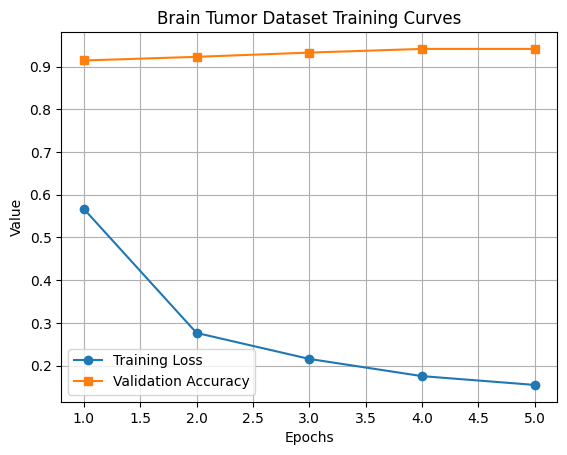

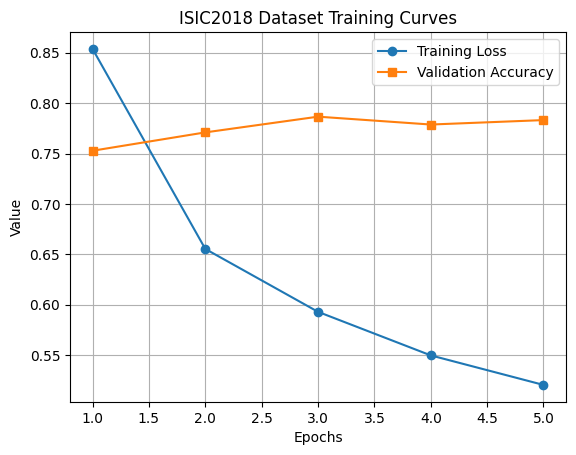

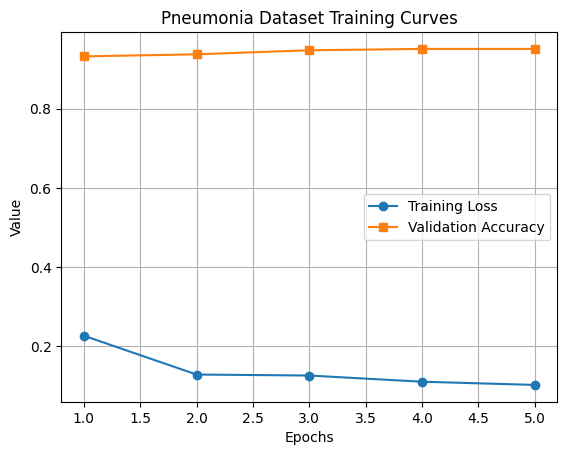

In [1]:
import matplotlib.pyplot as plt

# ---------------------------
# Data from logs
# ---------------------------

# Brain Tumor Dataset
epochs_bt = [1, 2, 3, 4, 5]
loss_bt = [0.5669, 0.2764, 0.2155, 0.1752, 0.1546]
val_acc_bt = [0.9145, 0.9231, 0.9330, 0.9416, 0.9416]

# ISIC2018 Dataset
epochs_isic = [1, 2, 3, 4, 5]
loss_isic = [0.8538, 0.6554, 0.5930, 0.5498, 0.5205]
val_acc_isic = [0.7528, 0.7710, 0.7866, 0.7788, 0.7832]

# Pneumonia Dataset
epochs_pn = [1, 2, 3, 4, 5]
loss_pn = [0.2270, 0.1290, 0.1265, 0.1109, 0.1028]
val_acc_pn = [0.9317, 0.9369, 0.9471, 0.9505, 0.9505]

# ---------------------------
# Plotting function
# ---------------------------
def plot_curves(epochs, loss, val_acc, title):
    plt.figure()

    plt.plot(epochs, loss, marker='o', label='Training Loss')
    plt.plot(epochs, val_acc, marker='s', label='Validation Accuracy')

    plt.xlabel('Epochs')
    plt.ylabel('Value')
    plt.title(title)
    plt.legend()
    plt.grid()

    plt.show()

# ---------------------------
# Generate plots
# ---------------------------
plot_curves(epochs_bt, loss_bt, val_acc_bt, "Brain Tumor Dataset Training Curves")
plot_curves(epochs_isic, loss_isic, val_acc_isic, "ISIC2018 Dataset Training Curves")
plot_curves(epochs_pn, loss_pn, val_acc_pn, "Pneumonia Dataset Training Curves")